Connected to .venv (Python 3.10.12)

In [ ]:
# IMPORTS
import os
import glob
import random
import logging
from typing import List, Tuple, Optional
import time
import copy

import numpy as np
import mne
import wfdb
import warnings

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import pandas as pd

import torch.ao.quantization as tq
from torch.ao.quantization import get_default_qconfig_mapping, get_default_qat_qconfig_mapping, get_default_qat_qconfig, fuse_modules
from torch.ao.quantization.quantize_fx import prepare_fx, prepare_qat_fx, convert_fx

warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", message="TypedStorage is deprecated")
warnings.filterwarnings("ignore", message="Please use quant_min and quant_max to specify the range for observers")
warnings.filterwarnings("ignore", message="must run observer before calling calculate_qparams")

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.expand_frame_repr", False)

 ---
 ### 1. CONFIGURATION

In [ ]:
# Path to the root folder containing CHB-MIT patient directories (chb01, chb02, ...)
#DATA_ROOT = "./dataset/chb-mit-1.0.0"
# DATA_ROOT = "/kaggle/input/seizure-epilepcy-chb-mit-eeg-dataset-pediatric/chb-mit-scalp-eeg-database-1.0.0"
DATA_ROOT = "chb-mit-scalp-eeg-database-1.0.0"

# Optional: folder to cache preprocessed arrays (will be created if it doesn't exist)
# PROCESSED_DIR = "/kaggle/working/processed_chb_mit"
PROCESSED_DIR = "processed_chb_mit"

# EEG bipolar channels to use (18 channels)
CHANNELS = [
    "FP1-F7", "F7-T7", "T7-P7", "P7-O1",
    "FP1-F3", "F3-C3", "C3-P3", "P3-O1",
    "FP2-F4", "F4-C4", "C4-P4", "P4-O2",
    "FP2-F8", "F8-T8", "T8-P8-1", "P8-O2",
    "FZ-CZ", "CZ-PZ",
]
# Windowing parameters
TIME_WINDOW = 8.0   # seconds per segment
TIME_STEP = 4.0     # seconds between segment starts

# Target sampling frequency after downsampling (CHB-MIT is originally 256 Hz)
TARGET_FS = 128.0

# Non-seizure sampling probability per candidate window (imbalance handling)
P_NON_SEIZURE = 0.01

# Train / test split at patient level
TRAIN_RATIO = 0.8

# Within-training set: validation split
VAL_RATIO = 0.3

# Random seeds for reproducibility
SEED = 2025

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Training parameters
LEARNING_RATE = 1e-4
BATCH_SIZE = 256
EPOCHS = 200
EARLY_STOPPING_PATIENCE = 20

 ---
 ### 2. SETUP & UTILITIES

In [ ]:
def setup_logging():
    os.makedirs(PROCESSED_DIR, exist_ok=True)
    logging.basicConfig(
        filename=os.path.join(PROCESSED_DIR, "preprocessing.log"),
        level=logging.INFO,
        format="%(asctime)s - %(levelname)s - %(message)s"
    )
    logging.getLogger().addHandler(logging.StreamHandler())


def set_random_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # extra reproducibility settings (optional but recommended)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def list_patient_dirs(root: str) -> List[str]:
    """Return sorted list of patient directory names (e.g. ['chb01', 'chb02', ...])."""
    dirs = sorted(
        d for d in os.listdir(root)
        if os.path.isdir(os.path.join(root, d)) and d.lower().startswith("chb")
    )
    return dirs


def split_patients(patients: List[str], train_ratio: float = TRAIN_RATIO) -> Tuple[List[str], List[str]]:
    """Split patient IDs into train and test sets."""
    n_train = int(round(train_ratio * len(patients)))
    train = sorted(random.sample(patients, n_train))
    test = sorted([p for p in patients if p not in train])
    return train, test


def collect_edf_files(root: str, patient_ids: List[str]) -> List[str]:
    """Collect all .edf files for given patient IDs."""
    files = []
    for pid in patient_ids:
        pattern = os.path.join(root, pid, "*.edf")
        files.extend(sorted(glob.glob(pattern)))
    return files

def processed_files_exist(processed_dir):
    required = [
        "X_train.npy", "y_train.npy",
        "X_val.npy", "y_val.npy",
        "X_test.npy", "y_test.npy",
    ]
    return all(os.path.exists(os.path.join(processed_dir, f)) for f in required)

 ---
 ### 3. Data Processing
 ---
 #### 3.1 SEIZURE ANNOTATIONS

In [ ]:
def load_seizure_mask(edf_path: str, n_samples: int, fs: float) -> np.ndarray:
    """
    Load seizure annotations for a given EDF file and return a binary mask
    of shape (n_samples,), where 1 indicates seizure.

    This assumes there is an annotation file with extension '.seizures'
    that WFDB can read via rdann.
    """
    mask = np.zeros(n_samples, dtype=np.int8)

    #record_base = os.path.splitext(edf_path)[0]  # includes path, without .edf
    record_base = edf_path
    ann_path = record_base + ".seizures"
    if not os.path.exists(ann_path):
        # No annotation file; treat as all non-seizure
        return mask

    try:
        # WFDB expects the "record name" without extension; can include path
        ann = wfdb.rdann(record_base, "seizures")
    except Exception as e:
        logging.warning(f"Failed to read annotation for {edf_path}: {e}")
        return mask

    # Typical assumption: ann.sample[0], ann.sample[1] are start/end of seizure 1, etc.
    samples = ann.sample
    if len(samples) < 2:
        return mask

    # Pair successive samples as start/end
    for start, end in zip(samples[0::2], samples[1::2]):
        start = max(0, int(start))
        end = min(n_samples, int(end))
        if end > start:
            mask[start:end] = 1

    return mask

 ---
 #### 3.2 PER-FILE WINDOWING

In [ ]:
def process_file_to_windows(
    edf_path: str,
    channels: List[str],
    time_window: float,
    time_step: float,
    target_fs: float,
    p_non_seizure: float
) -> Tuple[Optional[np.ndarray], Optional[np.ndarray]]:
    """
    Read one EDF file, extract sliding windows for the specified channels,
    and return:
        segments: (N_windows_selected, n_channels, n_time_samples)
        labels:   (N_windows_selected,) bool (True = seizure)

    Returns (None, None) if channels are not all present or no windows selected.
    """
    try:
        raw = mne.io.read_raw_edf(edf_path, preload=True, verbose="ERROR")
    except Exception as e:
        logging.warning(f"Failed to read {edf_path}: {e}")
        return None, None

    # Check channel availability
    available = set(raw.ch_names)
    if not all(ch in available for ch in channels):
        logging.info(f"Skipping {edf_path}: required channels missing.")
        return None, None

    raw.pick(channels)
    fs = float(raw.info["sfreq"])
    data = raw.get_data() * 1e6  # convert to microvolts
    n_channels, n_samples = data.shape

    # Build sample-level seizure mask (based on original sampling rate)
    sz_mask = load_seizure_mask(edf_path, n_samples, fs)

    # Downsample to target_fs by simple decimation (integer factor)
    if fs != target_fs:
        factor = int(round(fs / target_fs))
        if factor <= 0:
            raise ValueError(f"Invalid downsampling factor from fs={fs} to {target_fs}")
        data = data[:, ::factor]
        sz_mask = sz_mask[::factor]
        fs = fs / factor
        n_channels, n_samples = data.shape

    # Convert seconds to samples
    win_len = int(round(time_window * fs))
    step = int(round(time_step * fs))

    if n_samples < win_len:
        return None, None

    # Number of windows
    n_windows = 1 + (n_samples - win_len) // step
    if n_windows <= 0:
        return None, None

    # Compute seizure ratio for each window and keep segments in memory
    segs = []
    ratios = []

    for i in range(n_windows):
        start = i * step
        end = start + win_len
        seg = data[:, start:end]
        # Safety check for shape
        if seg.shape[1] != win_len:
            continue
        segs.append(seg)

        win_mask = sz_mask[start:end]
        ratio = win_mask.mean() if len(win_mask) > 0 else 0.0
        ratios.append(ratio)

    segs = np.stack(segs, axis=0)  # (n_windows, n_channels, win_len)
    ratios = np.array(ratios)

    # Select seizure and a subset of non-seizure windows
    idx_pos = np.where(ratios > 0.0)[0]
    idx_neg = np.where(ratios == 0.0)[0]

    selected_indices = []

    if len(idx_pos) > 0:
        selected_indices.append(idx_pos)

    if len(idx_neg) > 0 and p_non_seizure > 0.0:
        n_neg = int(round(p_non_seizure * len(idx_neg)))
        n_neg = max(0, min(n_neg, len(idx_neg)))
        if n_neg > 0:
            chosen_neg = np.random.choice(idx_neg, size=n_neg, replace=False)
            selected_indices.append(chosen_neg)

    if not selected_indices:
        return None, None

    selected_indices = np.concatenate(selected_indices)
    np.random.shuffle(selected_indices)

    segs = segs[selected_indices]
    labels = ratios[selected_indices] > 0.0  # bool: seizure if any seizure in window

    return segs, labels

 ---
  #### 3.3 DATASET BUILDING

In [ ]:
def build_dataset_from_files(files: List[str]) -> Tuple[np.ndarray, np.ndarray, float]:
    """
    Build dataset (segments, labels) from a list of EDF files.

    Returns:
        X: (N_segments, n_channels, n_time_samples)
        y: (N_segments,) bool
        fs: target sampling frequency used
    """
    all_segments = []
    all_labels = []

    for idx, fpath in enumerate(files):
        logging.info(f"[{idx + 1}/{len(files)}] Processing {fpath}")
        segs, labels = process_file_to_windows(
            fpath,
            channels=CHANNELS,
            time_window=TIME_WINDOW,
            time_step=TIME_STEP,
            target_fs=TARGET_FS,
            p_non_seizure=P_NON_SEIZURE
        )
        if segs is None:
            continue

        all_segments.append(segs)
        all_labels.append(labels)

    if not all_segments:
        raise RuntimeError("No segments were extracted from the provided files.")

    X = np.concatenate(all_segments, axis=0)
    y = np.concatenate(all_labels, axis=0)

    logging.info(f"Built dataset: X.shape={X.shape}, y.shape={y.shape}, "
                 f"seizure_ratio={y.mean():.4f}")

    return X, y.astype(bool), TARGET_FS

 ---
 ### 4. MODEL DEFINITION

In [ ]:
class EEGCNN(nn.Module):
    """
    2D CNN for EEG windows.

    Expects input of shape: (batch_size, 1, n_channels, n_time)
    Returns raw logits of shape: (batch_size, 1)
    """

    def __init__(self):
        super().__init__()

        # ---- Conv blocks ----
        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=64,
            kernel_size=(2, 4),
            padding=(1, 1),
        )
        self.conv2 = nn.Conv2d(
            in_channels=64,
            out_channels=64,
            kernel_size=(2, 4),
            stride=(1, 2),
            padding=(1, 1),
        )
        self.maxpool1 = nn.MaxPool2d(kernel_size=(1, 2))

        self.conv3 = nn.Conv2d(
            in_channels=64,
            out_channels=128,
            kernel_size=(2, 4),
            padding=(1, 1),
        )
        self.conv4 = nn.Conv2d(
            in_channels=128,
            out_channels=128,
            kernel_size=(2, 4),
            stride=(1, 2),
            padding=(1, 1),
        )
        self.maxpool2 = nn.MaxPool2d(kernel_size=(2, 2))

        self.conv5 = nn.Conv2d(
            in_channels=128,
            out_channels=256,
            kernel_size=(4, 4),
            padding=(1, 1),
        )
        self.conv6 = nn.Conv2d(
            in_channels=256,
            out_channels=256,
            kernel_size=(4, 4),
            stride=(1, 2),
            padding=(1, 1),
        )
        self.maxpool3 = nn.MaxPool2d(kernel_size=(1, 2))

        # ---- Global pooling ----
        self.global_avgpool = nn.AdaptiveAvgPool2d((1, 1))

        # ---- Fully connected head ----
        self.fc1 = nn.Linear(256, 256)
        self.dropout1 = nn.Dropout(0.25)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.dropout2 = nn.Dropout(0.25)
        self.fc4 = nn.Linear(64, 1)  # output logits (no sigmoid here!)

        # Optional: weight init (can help a bit)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        # x: (B, 1, C, T)
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.maxpool1(x)

        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = self.maxpool2(x)

        x = F.relu(self.conv5(x))
        x = F.relu(self.conv6(x))
        x = self.maxpool3(x)

        x = self.global_avgpool(x)       # (B, 256, 1, 1)
        x = torch.flatten(x, 1)          # (B, 256)

        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = self.dropout2(x)

        x = self.fc4(x)                  # logits, shape (B, 1)
        return x.squeeze(1)

 ---
 ### 5. TRAINING & EVALUATION

In [ ]:
def train_and_evaluate_o(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_val: np.ndarray,
    y_val: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray
):
    """
    Train the CNN (PyTorch) and evaluate on validation and test sets.
    Also records and plots training curves (train/val loss + LR).
    """

    # ---- prepare tensors & loaders ----
    X_train_t = torch.from_numpy(X_train).float().unsqueeze(1)  # (N,1,C,T)
    X_val_t   = torch.from_numpy(X_val).float().unsqueeze(1)
    X_test_t  = torch.from_numpy(X_test).float().unsqueeze(1)

    y_train_t = torch.from_numpy(y_train.astype(np.float32))
    y_val_t   = torch.from_numpy(y_val.astype(np.float32))
    y_test_t  = torch.from_numpy(y_test.astype(np.float32))

    train_ds = TensorDataset(X_train_t, y_train_t)
    val_ds   = TensorDataset(X_val_t, y_val_t)
    test_ds  = TensorDataset(X_test_t, y_test_t)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

    # ---- model, loss, optimizer, scheduler ----
    model = EEGCNN().to(DEVICE)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=5,
    )

    best_val_loss = float("inf")
    best_state = None
    epochs_no_improve = 0

    # history containers
    train_losses = []
    val_losses = []
    lrs = []

    # ---- training loop ----
    for epoch in range(1, EPOCHS + 1):
        model.train()
        running_loss = 0.0

        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * xb.size(0)

        train_loss = running_loss / len(train_loader.dataset)

        # ---- validation ----
        model.eval()
        val_running_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)
                logits = model(xb)
                loss = criterion(logits, yb)
                val_running_loss += loss.item() * xb.size(0)

        val_loss = val_running_loss / len(val_loader.dataset)

        # record history + lr
        current_lr = optimizer.param_groups[0]["lr"]
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        lrs.append(current_lr)

        # step LR scheduler
        scheduler.step(val_loss)

        print(f"Epoch {epoch:03d} | train_loss={train_loss:.4f} "
                f"| val_loss={val_loss:.4f} | lr={current_lr:.2e}")

        # early stopping
        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_state = model.state_dict()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
                print(f"Early stopping at epoch {epoch}")
                break

    # restore best weights
    if best_state is not None:
        model.load_state_dict(best_state)

    # ---- evaluation helper ----
    def eval_on_loader(loader):
        model.eval()
        all_probs, all_labels = [], []
        with torch.no_grad():
            for xb, yb in loader:
                xb = xb.to(DEVICE)
                logits = model(xb)
                probs = torch.sigmoid(logits)
                all_probs.append(probs.cpu().numpy())
                all_labels.append(yb.cpu().numpy())
        all_probs = np.concatenate(all_probs)
        all_labels = np.concatenate(all_labels)
        preds = (all_probs > 0.5).astype(int)
        return all_labels, all_probs, preds

    # ---- validation metrics ----
    y_val_true, y_val_probs, y_val_pred = eval_on_loader(val_loader)
    print("=== Validation report (threshold=0.5) ===")
    print(classification_report(y_val_true, y_val_pred, digits=4))
    try:
        val_auc = roc_auc_score(y_val_true, y_val_probs)
        print(f"Validation ROC AUC: {val_auc:.4f}")
    except ValueError:
        print("Validation ROC AUC: not defined (only one class present).")

    # ---- test metrics ----
    y_test_true, y_test_probs, y_test_pred = eval_on_loader(test_loader)
    print("=== Test report (threshold=0.5) ===")
    print(classification_report(y_test_true, y_test_pred, digits=4))
    try:
        test_auc = roc_auc_score(y_test_true, y_test_probs)
        print(f"Test ROC AUC: {test_auc:.4f}")
    except ValueError:
        print("Test ROC AUC: not defined (only one class present).")

    # ---- PLOTS: training curves ----
    epochs_range = range(1, len(train_losses) + 1)

    # Loss curves
    plt.figure(figsize=(6, 4))
    plt.plot(epochs_range, train_losses, label="Train loss")
    plt.plot(epochs_range, val_losses, label="Val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training / validation loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # LR curve
    plt.figure(figsize=(6, 4))
    plt.plot(epochs_range, lrs)
    plt.xlabel("Epoch")
    plt.ylabel("Learning rate")
    plt.title("Learning rate schedule")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    history = {
        "train_loss": train_losses,
        "val_loss": val_losses,
        "lr": lrs,
    }

    return model, history

def train_and_evaluate(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_val: np.ndarray,
    y_val: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray
):
    """
    Train the CNN (PyTorch) and evaluate on validation and test sets.
    Prints Keras-style logs and records training curves.
    Assumes EEGCNN.forward returns logits of shape (B,)
    and y_* are 0/1 arrays.
    """

    # ---- prepare tensors & loaders ----
    X_train_t = torch.from_numpy(X_train).float().unsqueeze(1)  # (N,1,C,T)
    X_val_t   = torch.from_numpy(X_val).float().unsqueeze(1)
    X_test_t  = torch.from_numpy(X_test).float().unsqueeze(1)

    y_train_t = torch.from_numpy(y_train.astype(np.float32))
    y_val_t   = torch.from_numpy(y_val.astype(np.float32))
    y_test_t  = torch.from_numpy(y_test.astype(np.float32))

    train_ds = TensorDataset(X_train_t, y_train_t)
    val_ds   = TensorDataset(X_val_t, y_val_t)
    test_ds  = TensorDataset(X_test_t, y_test_t)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

    # ---- model, loss, optimizer, scheduler ----
    model = EEGCNN().to(DEVICE)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=5,
    )

    best_val_loss = float("inf")
    best_state = None
    epochs_no_improve = 0

    # history containers
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    lrs = []

    # ---- training loop ----
    for epoch in range(1, EPOCHS + 1):
        epoch_start = time.time()

        # ----- TRAIN -----
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for step, (xb, yb) in enumerate(train_loader, start=1):
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()
            logits = model(xb)                  # (B,)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * xb.size(0)

            # accuracy
            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()
            correct += (preds == yb).sum().item()
            total += yb.numel()

        train_loss = running_loss / total
        train_acc = correct / total

        # ----- VALIDATION -----
        model.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)

                logits = model(xb)
                loss = criterion(logits, yb)
                val_running_loss += loss.item() * xb.size(0)

                probs = torch.sigmoid(logits)
                preds = (probs > 0.5).float()
                val_correct += (preds == yb).sum().item()
                val_total += yb.numel()

        val_loss = val_running_loss / val_total
        val_acc = val_correct / val_total

        # ---- scheduler + history ----
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]["lr"]

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        lrs.append(current_lr)

        epoch_time = time.time() - epoch_start
        steps_per_epoch = len(train_loader)
        ms_per_step = (epoch_time / steps_per_epoch) * 1000

        # Keras-style line
        print(f"{epoch}/{EPOCHS} - {epoch_time:.0f}s - {ms_per_step:.0f}ms/step "
              f"- accuracy: {train_acc:.4f} - loss: {train_loss:.4f} "
              f"- val_accuracy: {val_acc:.4f} - val_loss: {val_loss:.4f} "
              f"- lr: {current_lr:.2e}")

        # ---- early stopping ----
        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_state = model.state_dict()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
                print(f"Early stopping at epoch {epoch}")
                break

    # restore best weights
    if best_state is not None:
        model.load_state_dict(best_state)

    # ---- evaluation helper ----
    def eval_on_loader(loader):
        model.eval()
        all_probs, all_labels = [], []
        with torch.no_grad():
            for xb, yb in loader:
                xb = xb.to(DEVICE)
                logits = model(xb)              # (B,)
                probs = torch.sigmoid(logits)   # (B,)
                all_probs.append(probs.cpu().numpy())
                all_labels.append(yb.cpu().numpy())
        all_probs = np.concatenate(all_probs)
        all_labels = np.concatenate(all_labels)
        preds = (all_probs > 0.5).astype(int)
        return all_labels, all_probs, preds

    # ---- validation metrics ----
    y_val_true, y_val_probs, y_val_pred = eval_on_loader(val_loader)
    print("=== Validation report (threshold=0.5) ===")
    print(classification_report(y_val_true, y_val_pred, digits=4))
    try:
        val_auc = roc_auc_score(y_val_true, y_val_probs)
        print(f"Validation ROC AUC: {val_auc:.4f}")
    except ValueError:
        print("Validation ROC AUC: not defined (only one class present).")

    # ---- test metrics ----
    y_test_true, y_test_probs, y_test_pred = eval_on_loader(test_loader)
    print("=== Test report (threshold=0.5) ===")
    print(classification_report(y_test_true, y_test_pred, digits=4))
    try:
        test_auc = roc_auc_score(y_test_true, y_test_probs)
        print(f"Test ROC AUC: {test_auc:.4f}")
    except ValueError:
        print("Test ROC AUC: not defined (only one class present).")

    # ---- PLOTS: training curves ----
    epochs_range = range(1, len(train_losses) + 1)

    # Loss curves
    plt.figure(figsize=(6, 4))
    plt.plot(epochs_range, train_losses, label="Train loss")
    plt.plot(epochs_range, val_losses, label="Val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training / validation loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Accuracy curves (optional but useful)
    plt.figure(figsize=(6, 4))
    plt.plot(epochs_range, train_accs, label="Train accuracy")
    plt.plot(epochs_range, val_accs, label="Val accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training / validation accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # LR curve
    plt.figure(figsize=(6, 4))
    plt.plot(epochs_range, lrs)
    plt.xlabel("Epoch")
    plt.ylabel("Learning rate")
    plt.title("Learning rate schedule")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    history = {
        "train_loss": train_losses,
        "val_loss": val_losses,
        "train_acc": train_accs,
        "val_acc": val_accs,
        "lr": lrs,
    }

    return model, history

  ---
  ### 6. MAIN PIPELINE

In [ ]:
# 0. config & setup
setup_logging()
set_random_seeds(SEED)

def _save_state_dict_get_size_mb(state_dict, path):
    torch.save(state_dict, path)
    size_mb = os.path.getsize(path) / (1024.0 * 1024.0)
    return size_mb

def _predict_model_probs(model, X: np.ndarray, batch_size: int = 64, device: str = "cpu"):
    """
    Run model inference over X and return sigmoid probabilities as a 1D numpy array.
    """
    try:
        model_dev = copy.deepcopy(model)
    except Exception:
        model_dev = model

    try:
        model_dev = model_dev.to(device)
    except Exception:
        try:
            model_dev = model_dev.cpu()
            device = "cpu"
        except Exception:
            pass

    model_dev.eval()

    X_t = torch.from_numpy(X).float().unsqueeze(1)
    all_probs = []
    with torch.no_grad():
        for i in range(0, X_t.size(0), batch_size):
            xb = X_t[i:i+batch_size].to(device)
            try:
                logits = model_dev(xb)
            except Exception:
                logits = model_dev(xb)

            if hasattr(logits, "dequantize"):
                try:
                    logits = logits.dequantize()
                except Exception:
                    pass

            try:
                logits = logits.float()
            except Exception:
                pass

            probs = torch.sigmoid(logits).detach().cpu().numpy().ravel()
            if np.isnan(probs).any() or np.isinf(probs).any():
                logging.warning(f"_predict_model_probs: NaN/Inf detected in batch {i}")
                return None
            all_probs.append(probs)

    if not all_probs:
        return None
    return np.concatenate(all_probs, axis=0)

def evaluate_model_torch(model, X: np.ndarray, y: np.ndarray, batch_size: int = 64, device: str = "cpu"):
    """
    Evaluate model on (X, y) and return ROC AUC (or None if undefined).
    Model will be moved to CPU for evaluation.
    """
    all_probs = _predict_model_probs(model, X, batch_size=batch_size, device=device)
    if all_probs is None:
        return None
    try:
        auc = roc_auc_score(y, all_probs)
        return auc
    except ValueError:
        return None

def measure_avg_inference_time(model, X: np.ndarray, n_repeats: int = 3, device: str = "cpu"):
    """Measure average per-sample inference time (seconds) on CPU.
    Runs full pass over X `n_repeats` times and returns mean time/sample.
    """
    # Some quantized models cannot be deep-copied; try deepcopy then fallback
    try:
        model_dev = copy.deepcopy(model)
    except Exception:
        model_dev = model

    # Try move model to desired device; fall back to CPU if not supported
    try:
        model_dev = model_dev.to(device)
    except Exception:
        try:
            model_dev = model_dev.cpu()
            device = "cpu"
        except Exception:
            pass

    model_dev.eval()

    X_t = torch.from_numpy(X).float().unsqueeze(1).to(device)
    n_samples = X_t.size(0)

    total_per_sample = 0.0
    for _ in range(n_repeats):
        t0 = time.time()
        with torch.no_grad():
            # iterate in small batches to avoid huge memory but keep timings stable
            for i in range(0, n_samples, 16):
                xb = X_t[i:i+16]
                try:
                    _ = model_dev(xb)
                except Exception as e:
                    # fallback: try single-sample forward to isolate error
                    try:
                        _ = model_dev(xb[:1])
                    except Exception as e2:
                        logging.warning(f"measure_avg_inference_time: forward failed on batch starting {i}: {e2}")
                        return None
        t1 = time.time()
        total_per_sample += (t1 - t0) / float(n_samples)

    return total_per_sample / float(n_repeats)

def _safe_round(value, digits=4):
    if value is None:
        return np.nan
    try:
        value = float(value)
    except (TypeError, ValueError):
        return np.nan
    if np.isnan(value) or np.isinf(value):
        return np.nan
    return round(value, digits)

def _safe_int(value):
    if value is None:
        return 0
    try:
        return int(round(float(value)))
    except (TypeError, ValueError):
        return 0

def _base_metrics_for_prefix(prefix: str) -> List[str]:
    cols = [f"{prefix} ROC AUC"]
    for label in (0, 1):
        cols.extend([
            f"{prefix} Precision {label}",
            f"{prefix} Recall {label}",
            f"{prefix} F1 {label}",
            f"{prefix} Support {label}",
        ])
    cols.extend([
        f"{prefix} Accuracy",
        f"{prefix} Macro Precision",
        f"{prefix} Macro Recall",
        f"{prefix} Macro F1",
        f"{prefix} Weighted Precision",
        f"{prefix} Weighted Recall",
        f"{prefix} Weighted F1",
    ])
    return cols

def _build_prefix_columns(prefix: str) -> List[str]:
    cols = []
    for base in _base_metrics_for_prefix(prefix):
        cols.append(base)
        cols.append(f"{base} Δ")
        cols.append(f"{base} Δ%")
    return cols

BASE_PREFIX_COLUMN_MAP = {
    "Val": _base_metrics_for_prefix("Val"),
    "Test": _base_metrics_for_prefix("Test"),
}
PREFIX_COLUMN_MAP = {
    "Val": _build_prefix_columns("Val"),
    "Test": _build_prefix_columns("Test"),
}
BASE_CLASS_COLUMNS = BASE_PREFIX_COLUMN_MAP["Val"] + BASE_PREFIX_COLUMN_MAP["Test"]
CLASS_COLUMNS = PREFIX_COLUMN_MAP["Val"] + PREFIX_COLUMN_MAP["Test"]

def _is_valid_number(value):
    if value is None:
        return False
    if isinstance(value, (int, float, np.integer, np.floating)):
        try:
            return not np.isnan(float(value))
        except Exception:
            return False
    return False

def _delta_value(current, baseline, digits=6):
    if _is_valid_number(current) and _is_valid_number(baseline):
        return round(float(current) - float(baseline), digits)
    return None

def _delta_pct(current, baseline):
    if _is_valid_number(current) and _is_valid_number(baseline) and float(baseline) != 0.0:
        return pct(safe_pct(float(current), float(baseline)))
    return ""

def _metrics_from_probs(y_true: np.ndarray, probs: Optional[np.ndarray], prefix: str):
    metrics = {}
    base_cols = BASE_PREFIX_COLUMN_MAP[prefix]
    if probs is None or len(probs) == 0:
        for col in base_cols:
            metrics[col] = 0 if "Support" in col else np.nan
        return metrics

    probs = probs.ravel()
    y_true_int = y_true.astype(int)
    preds = (probs >= 0.5).astype(int)
    preds_int = preds.astype(int)

    report = classification_report(
        y_true_int,
        preds_int,
        digits=4,
        output_dict=True,
        zero_division=0
    )

    try:
        metrics[f"{prefix} ROC AUC"] = _safe_round(roc_auc_score(y_true_int, probs), 6)
    except ValueError:
        metrics[f"{prefix} ROC AUC"] = np.nan

    for label in (0, 1):
        key = str(label)
        cls_report = report.get(key)
        if cls_report is None:
            # classification_report may label floats as "0.0"
            cls_report = report.get(f"{float(label):.1f}", {})
        metrics[f"{prefix} Precision {label}"] = _safe_round(cls_report.get("precision"))
        metrics[f"{prefix} Recall {label}"] = _safe_round(cls_report.get("recall"))
        metrics[f"{prefix} F1 {label}"] = _safe_round(cls_report.get("f1-score"))
        metrics[f"{prefix} Support {label}"] = _safe_int(cls_report.get("support"))

    metrics[f"{prefix} Accuracy"] = _safe_round(report.get("accuracy"))

    macro = report.get("macro avg", {})
    metrics[f"{prefix} Macro Precision"] = _safe_round(macro.get("precision"))
    metrics[f"{prefix} Macro Recall"] = _safe_round(macro.get("recall"))
    metrics[f"{prefix} Macro F1"] = _safe_round(macro.get("f1-score"))

    weighted = report.get("weighted avg", {})
    metrics[f"{prefix} Weighted Precision"] = _safe_round(weighted.get("precision"))
    metrics[f"{prefix} Weighted Recall"] = _safe_round(weighted.get("recall"))
    metrics[f"{prefix} Weighted F1"] = _safe_round(weighted.get("f1-score"))

    return metrics

def _collect_dataset_metrics(model, X_split, y_split, prefix: str, batch_size: int = 64, device: str = "cpu"):
    probs = _predict_model_probs(model, X_split, batch_size=batch_size, device=device)
    return _metrics_from_probs(y_split, probs, prefix)

def collect_all_metrics_torch(model, batch_size: int = 64, device: str = "cpu"):
    metrics = {}
    metrics.update(_collect_dataset_metrics(model, X_val, y_val, "Val", batch_size=batch_size, device=device))
    metrics.update(_collect_dataset_metrics(model, X_test, y_test, "Test", batch_size=batch_size, device=device))
    return metrics

In [ ]:
# 1. Build train & test datasets
if processed_files_exist(PROCESSED_DIR):
    print("Loading cached preprocessed dataset...")

    X_train = np.load(os.path.join(PROCESSED_DIR, "X_train.npy"))
    y_train = np.load(os.path.join(PROCESSED_DIR, "y_train.npy"))
    X_val   = np.load(os.path.join(PROCESSED_DIR, "X_val.npy"))
    y_val   = np.load(os.path.join(PROCESSED_DIR, "y_val.npy"))
    X_test  = np.load(os.path.join(PROCESSED_DIR, "X_test.npy"))
    y_test  = np.load(os.path.join(PROCESSED_DIR, "y_test.npy"))
else:
    # 1) Get all patients and all EDF files
    patients = list_patient_dirs(DATA_ROOT)
    if not patients:
        raise RuntimeError(f"No patient directories found under {DATA_ROOT}")

    # Collect ALL EDF files from ALL patients
    all_files = collect_edf_files(DATA_ROOT, patients)
    print(f"Total EDF files: {len(all_files)}")

    # 2) Build one big dataset (all patients concatenated)
    print("Building full dataset from all patients...")
    X_all, y_all, fs_all = build_dataset_from_files(all_files)

    assert fs_all == TARGET_FS
    print(f"Full dataset: X_all = {X_all.shape}, y_all = {y_all.shape}")

    # 3) Split into train / val / test on the SEGMENT level
    #    Keep global proportions consistent with your old TRAIN_RATIO/VAL_RATIO:
    #    - First: TRAIN vs TEST using TRAIN_RATIO
    #    - Then: split TRAIN part into (train, val) with VAL_RATIO
    TEST_RATIO = 1.0 - TRAIN_RATIO

    # 3a) Train+Val vs Test
    X_temp, X_test, y_temp, y_test = train_test_split(
        X_all,
        y_all,
        test_size=TEST_RATIO,
        stratify=y_all,
        random_state=SEED,
    )

    # 3b) Train vs Val (inside the previous TRAIN part)
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp,
        y_temp,
        test_size=VAL_RATIO,
        stratify=y_temp,
        random_state=SEED,
    )

    print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
    print(f"X_val:   {X_val.shape}, y_val:   {y_val.shape}")
    print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")

    # 4) Save splits
    np.save(os.path.join(PROCESSED_DIR, "X_train.npy"), X_train)
    np.save(os.path.join(PROCESSED_DIR, "y_train.npy"), y_train)
    np.save(os.path.join(PROCESSED_DIR, "X_val.npy"), X_val)
    np.save(os.path.join(PROCESSED_DIR, "y_val.npy"), y_val)
    np.save(os.path.join(PROCESSED_DIR, "X_test.npy"), X_test)
    np.save(os.path.join(PROCESSED_DIR, "y_test.npy"), y_test)
    print(f"Datasets saved under: {PROCESSED_DIR}")

    print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
    print(f"X_val:   {X_val.shape}, y_val:   {y_val.shape}")
    print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")

[1/686] Processing chb-mit-scalp-eeg-database-1.0.0/chb01/chb01_01.edf


Total EDF files: 686
Building full dataset from all patients...


[2/686] Processing chb-mit-scalp-eeg-database-1.0.0/chb01/chb01_02.edf
[3/686] Processing chb-mit-scalp-eeg-database-1.0.0/chb01/chb01_03.edf
[4/686] Processing chb-mit-scalp-eeg-database-1.0.0/chb01/chb01_04.edf
[5/686] Processing chb-mit-scalp-eeg-database-1.0.0/chb01/chb01_05.edf
[6/686] Processing chb-mit-scalp-eeg-database-1.0.0/chb01/chb01_06.edf
[7/686] Processing chb-mit-scalp-eeg-database-1.0.0/chb01/chb01_07.edf
[8/686] Processing chb-mit-scalp-eeg-database-1.0.0/chb01/chb01_08.edf
[9/686] Processing chb-mit-scalp-eeg-database-1.0.0/chb01/chb01_09.edf
[10/686] Processing chb-mit-scalp-eeg-database-1.0.0/chb01/chb01_10.edf
[11/686] Processing chb-mit-scalp-eeg-database-1.0.0/chb01/chb01_11.edf
[12/686] Processing chb-mit-scalp-eeg-database-1.0.0/chb01/chb01_12.edf
[13/686] Processing chb-mit-scalp-eeg-database-1.0.0/chb01/chb01_13.edf
[14/686] Processing chb-mit-scalp-eeg-database-1.0.0/chb01/chb01_14.edf
[15/686] Processing chb-mit-scalp-eeg-database-1.0.0/chb01/chb01_15.edf


Full dataset: X_all = (11725, 18, 1024), y_all = (11725,)
X_train: (6566, 18, 1024), y_train: (6566,)
X_val:   (2814, 18, 1024), y_val:   (2814,)
X_test:  (2345, 18, 1024), y_test:  (2345,)
Datasets saved under: processed_chb_mit
X_train: (6566, 18, 1024), y_train: (6566,)
X_val:   (2814, 18, 1024), y_val:   (2814,)
X_test:  (2345, 18, 1024), y_test:  (2345,)


Training model from scratch...
1/200 - 13s - 513ms/step - accuracy: 0.5349 - loss: 12.9689 - val_accuracy: 0.7289 - val_loss: 1.1055 - lr: 1.00e-04
2/200 - 13s - 484ms/step - accuracy: 0.5436 - loss: 2.0616 - val_accuracy: 0.7370 - val_loss: 0.8054 - lr: 1.00e-04
3/200 - 13s - 484ms/step - accuracy: 0.5771 - loss: 1.1297 - val_accuracy: 0.6656 - val_loss: 0.6362 - lr: 1.00e-04
4/200 - 13s - 485ms/step - accuracy: 0.6037 - loss: 0.8720 - val_accuracy: 0.7484 - val_loss: 0.6602 - lr: 1.00e-04
5/200 - 13s - 485ms/step - accuracy: 0.6328 - loss: 0.7580 - val_accuracy: 0.7772 - val_loss: 0.6174 - lr: 1.00e-04
6/200 - 13s - 485ms/step - accuracy: 0.6599 - loss: 0.6993 - val_accuracy: 0.7655 - val_loss: 0.5830 - lr: 1.00e-04
7/200 - 13s - 486ms/step - accuracy: 0.7003 - loss: 0.6535 - val_accuracy: 0.7875 - val_loss: 0.5791 - lr: 1.00e-04
8/200 - 13s - 485ms/step - accuracy: 0.7111 - loss: 0.6322 - val_accuracy: 0.7914 - val_loss: 0.5681 - lr: 1.00e-04
9/200 - 13s - 485ms/step - accuracy: 0.7

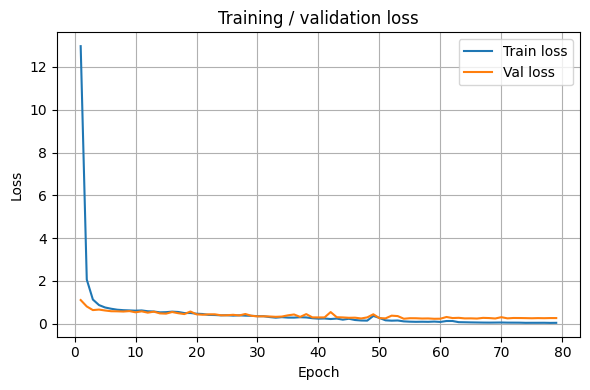

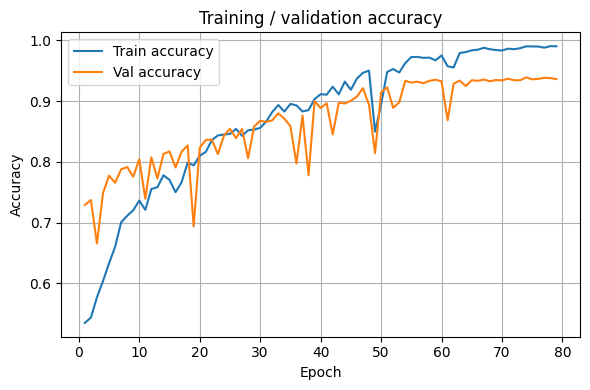

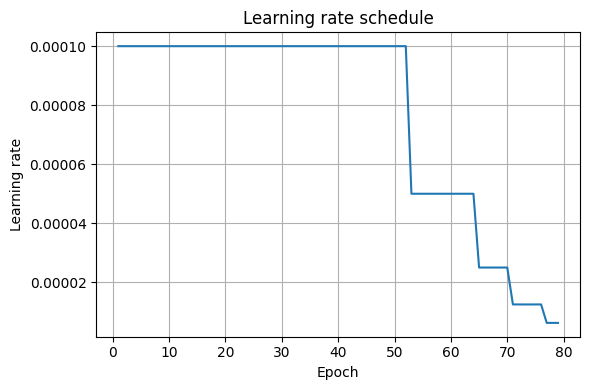

History saved to processed_chb_mit/seizure_cnn_history.pth
Model saved to processed_chb_mit/seizure_cnn_model.pth


In [ ]:
# 2. Train and evaluate model
model_path = os.path.join(PROCESSED_DIR, "seizure_cnn_model.pth")
history_path = os.path.join(PROCESSED_DIR, "seizure_cnn_history.pth")

if os.path.exists(model_path):
    print(f"Model exists loading from {model_path}")
    model = EEGCNN().to(DEVICE)
    state = torch.load(model_path, map_location=DEVICE)
    model.load_state_dict(state)
    model.eval()

    # Try to load saved training history if present
    history = None
    if os.path.exists(history_path):
        try:
            history = torch.load(history_path)
            print(f"Loaded training history from {history_path}")
        except Exception as e:
            logging.warning(f"Failed to load history from {history_path}: {e}")
            history = None
else:
    print("Training model from scratch...")
    model, history = train_and_evaluate(
        X_train, y_train,
        X_val, y_val,
        X_test, y_test
    )

    # Save FP32 model weights
    torch.save(model.state_dict(), model_path)

    # Save training history (if available)
    try:
        if history is not None:
            torch.save(history, history_path)
            print(f"History saved to {history_path}")
    except Exception as e:
        logging.warning(f"Failed to save history to {history_path}: {e}")

    print(f"Model saved to {model_path}")

# Now you have:
# - model: loaded or newly trained (FP32)
# - history: training history dict (loaded if available or saved after training)

In [ ]:
# 3. Calculating FP32 model size, inference time, and performance
try:
    # ensure `model` is present
    model_fp32 = copy.deepcopy(model).cpu().eval()
except Exception:
    model_fp32 = None

print("\n------------------------------------------------------------------------------------------------------------------------")
print("BASELINE F32 EVALUATION\n")
print("Calculating FP32 model size, inference time, and performance...")
# --- Save FP32 state_dict & size ---
fp32_state_path = os.path.join(PROCESSED_DIR, "model_fp32_state.pth")
fp32_size = _save_state_dict_get_size_mb(model_fp32.state_dict(), fp32_state_path)

# --- Evaluate FP32 performance (AUC) ---
print("Evaluating Baseline FP32 model (CPU)...")
model_fp32.eval()
fp32_auc = evaluate_model_torch(model_fp32, X_test, y_test, device="cpu")

# --- Measure FP32 inference time ---
print("Running inference speed comparison (CPU)...")
fp32_time = measure_avg_inference_time(model_fp32, X_test, n_repeats=2)

# --- Print FP32 results ---
print(f"FP32 model size: {fp32_size:.2f} MB")
print(f"FP32 avg inference time: {fp32_time*1000:.2f} ms")
print(f"FP32 ROC AUC: {fp32_auc}")


------------------------------------------------------------------------------------------------------------------------
BASELINE F32 EVALUATION

Calculating FP32 model size, inference time, and performance...
Evaluating Baseline FP32 model (CPU)...
Running inference speed comparison (CPU)...
FP32 model size: 7.30 MB
FP32 avg inference time: 7.99 ms
FP32 ROC AUC: 0.9525229083206705


 ---
### 7. MODEL QUANTIZATION & COMPARISONS
 ---
#### 1. DYNAMIC POST-TRAINING QUANTIZATION

In [ ]:
# 1. DYNAMIC POST-TRAINING QUANTIZATION
print("\n------------------------------------------------------------------------------------------------------------------------")
print("DYNAMIC POST-TRAINING QUANTIZATION\n")
int8_dyn_state_path = os.path.join(PROCESSED_DIR, "model_int8_dynamic_state.pth")

# --- Apply or load dynamic quantization (quantize Linear layers) ---
if os.path.exists(int8_dyn_state_path):
    print(f"Loading Dynamic INT8 state dict from {int8_dyn_state_path}")
    # create same quantized model structure then load saved state_dict
    model_int8_dynamic = torch.quantization.quantize_dynamic(
        copy.deepcopy(model_fp32),
        {nn.Linear},
        dtype=torch.qint8
    )
    try:
        state = torch.load(int8_dyn_state_path, map_location="cpu")
        model_int8_dynamic.load_state_dict(state)
        int8_dyn_size = os.path.getsize(int8_dyn_state_path) / (1024.0 * 1024.0)
    except Exception as e:
        logging.warning(f"Failed to load dynamic INT8 state from {int8_dyn_state_path}: {e}")
        # fallback: recreate quantized model and overwrite state file
        model_int8_dynamic = torch.quantization.quantize_dynamic(
            copy.deepcopy(model_fp32),
            {nn.Linear},
            dtype=torch.qint8
        )
        int8_dyn_size = _save_state_dict_get_size_mb(model_int8_dynamic.state_dict(), int8_dyn_state_path)
else:
    # File doesn't exist: quantize and save
    model_int8_dynamic = torch.quantization.quantize_dynamic(
        copy.deepcopy(model_fp32),
        {nn.Linear},
        dtype=torch.qint8
    )
    int8_dyn_size = _save_state_dict_get_size_mb(model_int8_dynamic.state_dict(), int8_dyn_state_path)

# --- Measure INT8 inference time (quantized models run on CPU) ---
print("Evaluating Dynamic INT8 model (CPU)...")
int8_dyn_time = measure_avg_inference_time(model_int8_dynamic, X_test, n_repeats=2, device='cpu')

# --- Evaluate INT8 dynamic performance (AUC) ---
print("Running inference speed comparison (CPU)...")
int8_dyn_auc = evaluate_model_torch(model_int8_dynamic, X_test, y_test, device='cpu')

RESULT_COLUMNS = [
    "Model",
    "Size (MB)",
    "Compression (x)",
    "Compression (%)",
    "Inference time (ms)",
    "Speedup Δ%",
    "AUC drop",
    "AUC Δ%"
] + CLASS_COLUMNS

results_df = pd.DataFrame(columns=RESULT_COLUMNS)

def pct(delta):
    if delta is None:
        return ""
    return f"{delta:+.2f}%"

def safe_pct(num, denom):
    try:
        return 100 * (num - denom) / denom
    except:
        return None

def add(name, model=None, size=None, inference_time=None, metrics=None, eval_device="cpu"):
    global results_df

    if metrics is None:
        if model is not None:
            metrics = collect_all_metrics_torch(model, device=eval_device)
        else:
            metrics = {}
            for col in BASE_CLASS_COLUMNS:
                metrics[col] = 0 if "Support" in col else np.nan

    test_auc = metrics.get("Test ROC AUC")
    # val metrics included within `metrics`
    size_mb = round(size, 4) if size is not None else None
    inference_ms = round(inference_time * 1000, 4) if inference_time is not None else None

    is_baseline = len(results_df) == 0
    base = results_df.iloc[0] if not is_baseline else None

    # Absolute values
    if is_baseline:
        compression_x = 1.0
        compression_pct = 0.0
        auc_drop = 0.0 if test_auc is not None else None
        acc_pct = 0.0 if test_auc is not None else None
        speed_pct = 0.0
    else:
        base_size = base["Size (MB)"]
        base_time = base["Inference time (ms)"]
        base_auc = base.get("Test ROC AUC")

        compression_x = None
        compression_pct = None
        if base_size not in (None, 0) and size_mb not in (None, 0):
            compression_x = base_size / size_mb
            compression_pct = (1 - size_mb / base_size) * 100

        auc_drop = None
        acc_pct = None
        if base_auc is not None and test_auc is not None:
            auc_drop = base_auc - test_auc
            acc_pct = safe_pct(test_auc, base_auc)

        speed_pct = None
        if base_time not in (None, 0) and inference_ms not in (None, 0):
            speed_pct = safe_pct(base_time, inference_ms)

    row = {
        "Model": name,
        "Size (MB)": size_mb,
        "Compression (x)": round(compression_x, 4) if compression_x is not None else None,
        "Compression (%)": round(compression_pct, 2) if compression_pct is not None else None,
        "Inference time (ms)": inference_ms,
        "Speedup Δ%": pct(speed_pct),
        "AUC drop": round(auc_drop, 6) if auc_drop is not None else None,
        "AUC Δ%": pct(acc_pct)
    }

    for col in BASE_CLASS_COLUMNS:
        value = metrics.get(col)
        row[col] = value
        delta_col = f"{col} Δ"
        delta_pct_col = f"{col} Δ%"
        if is_baseline:
            if _is_valid_number(value):
                row[delta_col] = 0 if isinstance(value, (int, np.integer)) else 0.0
                row[delta_pct_col] = "+0.00%"
            else:
                row[delta_col] = None
                row[delta_pct_col] = ""
        else:
            base_value = base.get(col)
            row[delta_col] = _delta_value(value, base_value)
            row[delta_pct_col] = _delta_pct(value, base_value)

    if is_baseline:
        results_df.loc[0] = row
    else:
        results_df.loc[len(results_df)] = row
# --- Record results ---
add("FP32", model=model_fp32, size=fp32_size, inference_time=fp32_time)
add("Dynamic INT8", model=model_int8_dynamic, size=int8_dyn_size, inference_time=int8_dyn_time)
print("Dynamic Quantization Comparison Finished!")
print(results_df.to_string(index=False))
results_df


------------------------------------------------------------------------------------------------------------------------
DYNAMIC POST-TRAINING QUANTIZATION

Evaluating Dynamic INT8 model (CPU)...
Running inference speed comparison (CPU)...
Dynamic Quantization Comparison Finished!
       Model  Size (MB)  Compression (x)  Compression (%)  Inference time (ms) Speedup Δ%  AUC drop AUC Δ%  Val ROC AUC  Val ROC AUC Δ Val ROC AUC Δ%  Val Precision 0  Val Precision 0 Δ Val Precision 0 Δ%  Val Recall 0  Val Recall 0 Δ Val Recall 0 Δ%  Val F1 0  Val F1 0 Δ Val F1 0 Δ%  Val Support 0  Val Support 0 Δ Val Support 0 Δ%  Val Precision 1  Val Precision 1 Δ Val Precision 1 Δ%  Val Recall 1  Val Recall 1 Δ Val Recall 1 Δ%  Val F1 1  Val F1 1 Δ Val F1 1 Δ%  Val Support 1  Val Support 1 Δ Val Support 1 Δ%  Val Accuracy  Val Accuracy Δ Val Accuracy Δ%  Val Macro Precision  Val Macro Precision Δ Val Macro Precision Δ%  Val Macro Recall  Val Macro Recall Δ Val Macro Recall Δ%  Val Macro F1  Val Macro F1 

,Model,Size (MB),Compression (x),Compression (%),Inference time (ms),Speedup Δ%,AUC drop,AUC Δ%,Val ROC AUC,Val ROC AUC Δ,Val ROC AUC Δ%,Val Precision 0,Val Precision 0 Δ,Val Precision 0 Δ%,Val Recall 0,Val Recall 0 Δ,Val Recall 0 Δ%,Val F1 0,Val F1 0 Δ,Val F1 0 Δ%,Val Support 0,Val Support 0 Δ,Val Support 0 Δ%,Val Precision 1,Val Precision 1 Δ,Val Precision 1 Δ%,Val Recall 1,Val Recall 1 Δ,Val Recall 1 Δ%,Val F1 1,Val F1 1 Δ,Val F1 1 Δ%,Val Support 1,Val Support 1 Δ,Val Support 1 Δ%,Val Accuracy,Val Accuracy Δ,Val Accuracy Δ%,Val Macro Precision,Val Macro Precision Δ,Val Macro Precision Δ%,Val Macro Recall,Val Macro Recall Δ,Val Macro Recall Δ%,Val Macro F1,Val Macro F1 Δ,Val Macro F1 Δ%,Val Weighted Precision,Val Weighted Precision Δ,Val Weighted Precision Δ%,Val Weighted Recall,Val Weighted Recall Δ,Val Weighted Recall Δ%,Val Weighted F1,Val Weighted F1 Δ,Val Weighted F1 Δ%,Test ROC AUC,Test ROC AUC Δ,Test ROC AUC Δ%,Test Precision 0,Test Precision 0 Δ,Test Precision 0 Δ%,Test Recall 0,Test Recall 0 Δ,Test Recall 0 Δ%,Test F1 0,Test F1 0 Δ,Test F1 0 Δ%,Test Support 0,Test Support 0 Δ,Test Support 0 Δ%,Test Precision 1,Test Precision 1 Δ,Test Precision 1 Δ%,Test Recall 1,Test Recall 1 Δ,Test Recall 1 Δ%,Test F1 1,Test F1 1 Δ,Test F1 1 Δ%,Test Support 1,Test Support 1 Δ,Test Support 1 Δ%,Test Accuracy,Test Accuracy Δ,Test Accuracy Δ%,Test Macro Precision,Test Macro Precision Δ,Test Macro Precision Δ%,Test Macro Recall,Test Macro Recall Δ,Test Macro Recall Δ%,Test Macro F1,Test Macro F1 Δ,Test Macro F1 Δ%,Test Weighted Precision,Test Weighted Precision Δ,Test Weighted Precision Δ%,Test Weighted Recall,Test Weighted Recall Δ,Test Weighted Recall Δ%,Test Weighted F1,Test Weighted F1 Δ,Test Weighted F1 Δ%
0,FP32,7.2955,1.0000,0.00,7.9920,+0.00%,0.00000,+0.00%,0.956380,0.000000,+0.00%,0.9478,0.000,+0.00%,0.9654,0.0000,+0.00%,0.9565,0.0000,+0.00%,2052,0.0,+0.00%,0.9019,0.0000,+0.00%,0.8570,0.0000,+0.00%,0.8789,0.0000,+0.00%,762,0.0,+0.00%,0.9360,0.0000,+0.00%,0.9249,0.0000,+0.00%,0.9112,0.0000,+0.00%,0.9177,0.0000,+0.00%,0.9354,0.0000,+0.00%,0.9360,0.0000,+0.00%,0.9355,0.0000,+0.00%,0.952523,0.00000,+0.00%,0.9434,0.000,+0.00%,0.9643,0.0000,+0.00%,0.9537,0.0000,+0.00%,1710,0.0,+0.00%,0.8978,0.0000,+0.00%,0.8441,0.0000,+0.00%,0.8701,0.0000,+0.00%,635,0.0,+0.00%,0.9318,0.000,+0.00%,0.9206,0.0000,+0.00%,0.9042,0.0000,+0.00%,0.9119,0.0000,+0.00%,0.9310,0.0000,+0.00%,0.9318,0.000,+0.00%,0.9311,0.0000,+0.00%
1,Dynamic INT8,6.9935,1.0432,4.14,6.8402,+16.84%,0.00252,-0.26%,0.954437,-0.001943,-0.20%,0.9458,-0.002,-0.21%,0.9693,0.0039,+0.40%,0.9574,0.0009,+0.09%,2052,0.0,+0.00%,0.9114,0.0095,+1.05%,0.8504,-0.0066,-0.77%,0.8798,0.0009,+0.10%,762,0.0,+0.00%,0.9371,0.0011,+0.12%,0.9286,0.0037,+0.40%,0.9098,-0.0014,-0.15%,0.9186,0.0009,+0.10%,0.9365,0.0011,+0.12%,0.9371,0.0011,+0.12%,0.9364,0.0009,+0.10%,0.950003,-0.00252,-0.26%,0.9364,-0.007,-0.74%,0.9637,-0.0006,-0.06%,0.9499,-0.0038,-0.40%,1710,0.0,+0.00%,0.8940,-0.0038,-0.42%,0.8236,-0.0205,-2.43%,0.8574,-0.0127,-1.46%,635,0.0,+0.00%,0.9258,-0.006,-0.64%,0.9152,-0.0054,-0.59%,0.8937,-0.0105,-1.16%,0.9036,-0.0083,-0.91%,0.9249,-0.0061,-0.66%,0.9258,-0.006,-0.64%,0.9248,-0.0063,-0.68%


 ---
#### 2. STATIC (EAGER) POST-TRAINING QUANTIZATION

In [ ]:
# 2. STATIC (EAGER) POST-TRAINING QUANTIZATION
print("\n------------------------------------------------------------------------------------------------------------------------")
print("STATIC (EAGER) POST-TRAINING QUANTIZATION\n")

# Use fbgemm backend for x86 CPUs
torch.backends.quantized.engine = "fbgemm"

# -----------------------------
# 1. Calibration DataLoader
# -----------------------------
def get_calibration_loader_eager(X, batch_size=32, n_samples=512):
    """Small subset of training data for calibration."""
    idx = np.random.choice(len(X), size=min(n_samples, len(X)), replace=False)
    X_cal = torch.from_numpy(X[idx]).float().unsqueeze(1)  # (N,1,C,T)
    dummy_y = torch.zeros(len(X_cal))  # labels not needed
    ds = TensorDataset(X_cal, dummy_y)
    return DataLoader(ds, batch_size=batch_size, shuffle=False)

calib_loader_eager = get_calibration_loader_eager(X_train)

# -----------------------------
# 2. Wrapper with QuantStub / DeQuantStub
# -----------------------------
class QuantWrapper(nn.Module):
    """
    Wraps an existing float model with QuantStub and DeQuantStub
    so we can use eager static quantization without touching EEGCNN.
    """
    def __init__(self, float_model: nn.Module):
        super().__init__()
        self.quant = tq.QuantStub()
        self.model = float_model
        self.dequant = tq.DeQuantStub()

    def forward(self, x):
        x = self.quant(x)
        x = self.model(x)
        x = self.dequant(x)
        return x

# Start from baseline FP32 model
float_model_for_q = copy.deepcopy(model_fp32).cpu().eval()

# Wrap with QuantStub/DeQuantStub
eager_quant_model = QuantWrapper(float_model_for_q).cpu().eval()

# -----------------------------
# 3. Assign qconfig and prepare
# -----------------------------
# Default per-tensor int8 config for static quantization (fbgemm backend)
eager_quant_model.qconfig = tq.get_default_qconfig("fbgemm")

print("Preparing model for eager static quantization...")
tq.prepare(eager_quant_model, inplace=True)

# -----------------------------
# 4. Calibration (run some real data through)
# -----------------------------
print("Running calibration over subset of training data...")
with torch.no_grad():
    for xb, _ in calib_loader_eager:
        xb = xb.to("cpu")
        _ = eager_quant_model(xb)

# -----------------------------
# 5. Convert to quantized model
# -----------------------------
print("Converting to quantized int8 model (eager)...")
model_int8_static_eager = tq.convert(eager_quant_model, inplace=False).eval()

print("Eager static quantization done.")

# -----------------------------
# 6. Save model & compare size (load if exists)
# -----------------------------
int8_static_eager_path = os.path.join(PROCESSED_DIR, "model_int8_static_eager_state.pth")

# If a saved eager static state_dict exists, try to load it into a converted
# model instance. Otherwise perform conversion and save the state_dict.
if os.path.exists(int8_static_eager_path):
    print(f"Loading Static Eager INT8 state dict from {int8_static_eager_path}")
    try:
        # Recreate the converted model structure (may skip calibration)
        float_model_for_q = copy.deepcopy(model_fp32).cpu().eval()
        eager_quant_model = QuantWrapper(float_model_for_q).cpu().eval()
        eager_quant_model.qconfig = tq.get_default_qconfig("fbgemm")
        # Prepare and convert (without a full calibration pass) to obtain
        # the quantized module structure; then load saved params.
        tq.prepare(eager_quant_model, inplace=True)
        model_int8_static_eager = tq.convert(eager_quant_model, inplace=False).eval()

        state = torch.load(int8_static_eager_path, map_location="cpu")
        model_int8_static_eager.load_state_dict(state)
        int8_static_eager_size = os.path.getsize(int8_static_eager_path) / (1024.0 * 1024.0)
    except Exception as e:
        logging.warning(f"Failed to load static eager INT8 state from {int8_static_eager_path}: {e}")
        # Fallback: run full calibration+convert and overwrite saved file
        print("Fallback: running calibration + convert for Static Eager INT8...")
        tq.prepare(eager_quant_model, inplace=True)
        print("Running calibration over subset of training data...")
        with torch.no_grad():
            for xb, _ in calib_loader_eager:
                xb = xb.to("cpu")
                _ = eager_quant_model(xb)
        model_int8_static_eager = tq.convert(eager_quant_model, inplace=False).eval()
        int8_static_eager_size = _save_state_dict_get_size_mb(
            model_int8_static_eager.state_dict(),
            int8_static_eager_path
        )
else:
    int8_static_eager_path = os.path.join(PROCESSED_DIR, "model_int8_static_eager_state.pth")
    int8_static_eager_size = _save_state_dict_get_size_mb(
        model_int8_static_eager.state_dict(),
        int8_static_eager_path
    )

print("Evaluating Static Eager INT8 model (CPU)...")
# quantized ops only supported on CPU
static_eager_auc = evaluate_model_torch(model_int8_static_eager, X_test, y_test, device="cpu")
print("Running inference speed comparison (CPU)...")
static_eager_time = measure_avg_inference_time(model_int8_static_eager, X_test, n_repeats=2, device="cpu")
add("Static Eager INT8", model=model_int8_static_eager, size=int8_static_eager_size, inference_time=static_eager_time)
print("Static Eager INT8 Quantization Comparison Finished!")
print(results_df.to_string(index=False))
results_df


------------------------------------------------------------------------------------------------------------------------
STATIC (EAGER) POST-TRAINING QUANTIZATION

Preparing model for eager static quantization...
Running calibration over subset of training data...
Converting to quantized int8 model (eager)...
Eager static quantization done.
Evaluating Static Eager INT8 model (CPU)...
Running inference speed comparison (CPU)...
Static Eager INT8 Quantization Comparison Finished!
            Model  Size (MB)  Compression (x)  Compression (%)  Inference time (ms) Speedup Δ%  AUC drop AUC Δ%  Val ROC AUC  Val ROC AUC Δ Val ROC AUC Δ%  Val Precision 0  Val Precision 0 Δ Val Precision 0 Δ%  Val Recall 0  Val Recall 0 Δ Val Recall 0 Δ%  Val F1 0  Val F1 0 Δ Val F1 0 Δ%  Val Support 0  Val Support 0 Δ Val Support 0 Δ%  Val Precision 1  Val Precision 1 Δ Val Precision 1 Δ%  Val Recall 1  Val Recall 1 Δ Val Recall 1 Δ%  Val F1 1  Val F1 1 Δ Val F1 1 Δ%  Val Support 1  Val Support 1 Δ Val Suppor

,Model,Size (MB),Compression (x),Compression (%),Inference time (ms),Speedup Δ%,AUC drop,AUC Δ%,Val ROC AUC,Val ROC AUC Δ,Val ROC AUC Δ%,Val Precision 0,Val Precision 0 Δ,Val Precision 0 Δ%,Val Recall 0,Val Recall 0 Δ,Val Recall 0 Δ%,Val F1 0,Val F1 0 Δ,Val F1 0 Δ%,Val Support 0,Val Support 0 Δ,Val Support 0 Δ%,Val Precision 1,Val Precision 1 Δ,Val Precision 1 Δ%,Val Recall 1,Val Recall 1 Δ,Val Recall 1 Δ%,Val F1 1,Val F1 1 Δ,Val F1 1 Δ%,Val Support 1,Val Support 1 Δ,Val Support 1 Δ%,Val Accuracy,Val Accuracy Δ,Val Accuracy Δ%,Val Macro Precision,Val Macro Precision Δ,Val Macro Precision Δ%,Val Macro Recall,Val Macro Recall Δ,Val Macro Recall Δ%,Val Macro F1,Val Macro F1 Δ,Val Macro F1 Δ%,Val Weighted Precision,Val Weighted Precision Δ,Val Weighted Precision Δ%,Val Weighted Recall,Val Weighted Recall Δ,Val Weighted Recall Δ%,Val Weighted F1,Val Weighted F1 Δ,Val Weighted F1 Δ%,Test ROC AUC,Test ROC AUC Δ,Test ROC AUC Δ%,Test Precision 0,Test Precision 0 Δ,Test Precision 0 Δ%,Test Recall 0,Test Recall 0 Δ,Test Recall 0 Δ%,Test F1 0,Test F1 0 Δ,Test F1 0 Δ%,Test Support 0,Test Support 0 Δ,Test Support 0 Δ%,Test Precision 1,Test Precision 1 Δ,Test Precision 1 Δ%,Test Recall 1,Test Recall 1 Δ,Test Recall 1 Δ%,Test F1 1,Test F1 1 Δ,Test F1 1 Δ%,Test Support 1,Test Support 1 Δ,Test Support 1 Δ%,Test Accuracy,Test Accuracy Δ,Test Accuracy Δ%,Test Macro Precision,Test Macro Precision Δ,Test Macro Precision Δ%,Test Macro Recall,Test Macro Recall Δ,Test Macro Recall Δ%,Test Macro F1,Test Macro F1 Δ,Test Macro F1 Δ%,Test Weighted Precision,Test Weighted Precision Δ,Test Weighted Precision Δ%,Test Weighted Recall,Test Weighted Recall Δ,Test Weighted Recall Δ%,Test Weighted F1,Test Weighted F1 Δ,Test Weighted F1 Δ%
0,FP32,7.2955,1.0000,0.00,7.9920,+0.00%,0.000000,+0.00%,0.956380,0.000000,+0.00%,0.9478,0.0000,+0.00%,0.9654,0.0000,+0.00%,0.9565,0.0000,+0.00%,2052,0.0,+0.00%,0.9019,0.0000,+0.00%,0.8570,0.0000,+0.00%,0.8789,0.0000,+0.00%,762,0.0,+0.00%,0.9360,0.0000,+0.00%,0.9249,0.0000,+0.00%,0.9112,0.0000,+0.00%,0.9177,0.0000,+0.00%,0.9354,0.0000,+0.00%,0.9360,0.0000,+0.00%,0.9355,0.0000,+0.00%,0.952523,0.000000,+0.00%,0.9434,0.0000,+0.00%,0.9643,0.0000,+0.00%,0.9537,0.0000,+0.00%,1710,0.0,+0.00%,0.8978,0.0000,+0.00%,0.8441,0.0000,+0.00%,0.8701,0.0000,+0.00%,635,0.0,+0.00%,0.9318,0.0000,+0.00%,0.9206,0.0000,+0.00%,0.9042,0.0000,+0.00%,0.9119,0.0000,+0.00%,0.9310,0.0000,+0.00%,0.9318,0.0000,+0.00%,0.9311,0.0000,+0.00%
1,Dynamic INT8,6.9935,1.0432,4.14,6.8402,+16.84%,0.002520,-0.26%,0.954437,-0.001943,-0.20%,0.9458,-0.0020,-0.21%,0.9693,0.0039,+0.40%,0.9574,0.0009,+0.09%,2052,0.0,+0.00%,0.9114,0.0095,+1.05%,0.8504,-0.0066,-0.77%,0.8798,0.0009,+0.10%,762,0.0,+0.00%,0.9371,0.0011,+0.12%,0.9286,0.0037,+0.40%,0.9098,-0.0014,-0.15%,0.9186,0.0009,+0.10%,0.9365,0.0011,+0.12%,0.9371,0.0011,+0.12%,0.9364,0.0009,+0.10%,0.950003,-0.002520,-0.26%,0.9364,-0.0070,-0.74%,0.9637,-0.0006,-0.06%,0.9499,-0.0038,-0.40%,1710,0.0,+0.00%,0.8940,-0.0038,-0.42%,0.8236,-0.0205,-2.43%,0.8574,-0.0127,-1.46%,635,0.0,+0.00%,0.9258,-0.0060,-0.64%,0.9152,-0.0054,-0.59%,0.8937,-0.0105,-1.16%,0.9036,-0.0083,-0.91%,0.9249,-0.0061,-0.66%,0.9258,-0.0060,-0.64%,0.9248,-0.0063,-0.68%
2,Static Eager INT8,1.8665,3.9087,74.42,3.1317,+155.20%,0.080208,-8.42%,0.879422,-0.076958,-8.05%,0.8929,-0.0549,-5.79%,0.9020,-0.0634,-6.57%,0.8975,-0.0590,-6.17%,2052,0.0,+0.00%,0.7287,-0.1732,-19.20%,0.7087,-0.1483,-17.30%,0.7186,-0.1603,-18.24%,762,0.0,+0.00%,0.8497,-0.0863,-9.22%,0.8108,-0.1141,-12.34%,0.8054,-0.1058,-11.61%,0.8080,-0.1097,-11.95%,0.8485,-0.0869,-9.29%,0.8497,-0.0863,-9.22%,0.8490,-0.0865,-9.25%,0.872315,-0.080208,-8.42%,0.8943,-0.0491,-5.20%,0.8953,-0.0690,-7.16%,0.8948,-0.0589,-6.18%,1710,0.0,+0.00%,0.7172,-0.1806,-20.12%,0.7150,-0.1291,-15.29%,0.7161,-0.1540,-17.70%,635,0.0,+0.00%,0.8465,-0.0853,-9.15%,0.8057,-0.1149,-12.48%,0.8051,-0.0991,-10.96%,0.8054,-0.1065,-11.68%,0.8463,-0.0847,-9.10%,0.8465,-0.0853,-9.15%,0.8464,-0.0847,-9.10%


 ---
#### 3. STATIC QUANTIZATION (FX GRAPH MODE)

In [ ]:
# 3. STATIC QUANTIZATION (FX GRAPH MODE)
print("\n------------------------------------------------------------------------------------------------------------------------")
print("STATIC FX QUANTIZATION\n")
print("Starting Static FX Quantization Comparison...")

# -----------------------------
# 1. Build Calibration Dataloader
# -----------------------------
def get_calibration_loader(X, batch_size=32, n_samples=512):
    idx = np.random.choice(len(X), size=min(n_samples, len(X)), replace=False)
    X_cal = torch.from_numpy(X[idx]).float().unsqueeze(1)
    dummy_y = torch.zeros(len(X_cal))
    ds = TensorDataset(X_cal, dummy_y)
    return DataLoader(ds, batch_size=batch_size, shuffle=False)

calibration_loader = get_calibration_loader(X_train)

model_static = copy.deepcopy(model_fp32).cpu().eval()

qconfig = get_default_qconfig_mapping("fbgemm")   # CPU int8 quantization backend

example_input = torch.randn(1, 1, X_train.shape[1], X_train.shape[2])
prepared_model = prepare_fx(model_static, qconfig, example_inputs=example_input)

print("Running calibration over sample training data...")
with torch.no_grad():
    for xb, _ in calibration_loader:
        prepared_model(xb)

model_int8_static = convert_fx(prepared_model)
print("Static FX quantization completed")

int8_static_path = os.path.join(PROCESSED_DIR, "model_int8_static_state.pth")
int8_static_size = _save_state_dict_get_size_mb(model_int8_static.state_dict(), int8_static_path)

print("Evaluating Static INT8 model...")
static_auc = evaluate_model_torch(model_int8_static, X_test, y_test, device="cpu")

print("Running inference speed comparison (CPU)...")
static_time = measure_avg_inference_time(model_int8_static, X_test, n_repeats=2, device="cpu")

add("Static FX INT8", model=model_int8_static, size=int8_static_size, inference_time=static_time)
print("Static FX Quantization Comparison Finished!")
print(results_df.to_string(index=False))
results_df


------------------------------------------------------------------------------------------------------------------------
STATIC FX QUANTIZATION

Starting Static FX Quantization Comparison...
Running calibration over sample training data...
Static FX quantization completed
Evaluating Static INT8 model...
Running inference speed comparison (CPU)...
Static FX Quantization Comparison Finished!
            Model  Size (MB)  Compression (x)  Compression (%)  Inference time (ms) Speedup Δ%  AUC drop AUC Δ%  Val ROC AUC  Val ROC AUC Δ Val ROC AUC Δ%  Val Precision 0  Val Precision 0 Δ Val Precision 0 Δ%  Val Recall 0  Val Recall 0 Δ Val Recall 0 Δ%  Val F1 0  Val F1 0 Δ Val F1 0 Δ%  Val Support 0  Val Support 0 Δ Val Support 0 Δ%  Val Precision 1  Val Precision 1 Δ Val Precision 1 Δ%  Val Recall 1  Val Recall 1 Δ Val Recall 1 Δ%  Val F1 1  Val F1 1 Δ Val F1 1 Δ%  Val Support 1  Val Support 1 Δ Val Support 1 Δ%  Val Accuracy  Val Accuracy Δ Val Accuracy Δ%  Val Macro Precision  Val Macro Preci

,Model,Size (MB),Compression (x),Compression (%),Inference time (ms),Speedup Δ%,AUC drop,AUC Δ%,Val ROC AUC,Val ROC AUC Δ,Val ROC AUC Δ%,Val Precision 0,Val Precision 0 Δ,Val Precision 0 Δ%,Val Recall 0,Val Recall 0 Δ,Val Recall 0 Δ%,Val F1 0,Val F1 0 Δ,Val F1 0 Δ%,Val Support 0,Val Support 0 Δ,Val Support 0 Δ%,Val Precision 1,Val Precision 1 Δ,Val Precision 1 Δ%,Val Recall 1,Val Recall 1 Δ,Val Recall 1 Δ%,Val F1 1,Val F1 1 Δ,Val F1 1 Δ%,Val Support 1,Val Support 1 Δ,Val Support 1 Δ%,Val Accuracy,Val Accuracy Δ,Val Accuracy Δ%,Val Macro Precision,Val Macro Precision Δ,Val Macro Precision Δ%,Val Macro Recall,Val Macro Recall Δ,Val Macro Recall Δ%,Val Macro F1,Val Macro F1 Δ,Val Macro F1 Δ%,Val Weighted Precision,Val Weighted Precision Δ,Val Weighted Precision Δ%,Val Weighted Recall,Val Weighted Recall Δ,Val Weighted Recall Δ%,Val Weighted F1,Val Weighted F1 Δ,Val Weighted F1 Δ%,Test ROC AUC,Test ROC AUC Δ,Test ROC AUC Δ%,Test Precision 0,Test Precision 0 Δ,Test Precision 0 Δ%,Test Recall 0,Test Recall 0 Δ,Test Recall 0 Δ%,Test F1 0,Test F1 0 Δ,Test F1 0 Δ%,Test Support 0,Test Support 0 Δ,Test Support 0 Δ%,Test Precision 1,Test Precision 1 Δ,Test Precision 1 Δ%,Test Recall 1,Test Recall 1 Δ,Test Recall 1 Δ%,Test F1 1,Test F1 1 Δ,Test F1 1 Δ%,Test Support 1,Test Support 1 Δ,Test Support 1 Δ%,Test Accuracy,Test Accuracy Δ,Test Accuracy Δ%,Test Macro Precision,Test Macro Precision Δ,Test Macro Precision Δ%,Test Macro Recall,Test Macro Recall Δ,Test Macro Recall Δ%,Test Macro F1,Test Macro F1 Δ,Test Macro F1 Δ%,Test Weighted Precision,Test Weighted Precision Δ,Test Weighted Precision Δ%,Test Weighted Recall,Test Weighted Recall Δ,Test Weighted Recall Δ%,Test Weighted F1,Test Weighted F1 Δ,Test Weighted F1 Δ%
0,FP32,7.2955,1.0000,0.00,7.9920,+0.00%,0.000000,+0.00%,0.956380,0.000000,+0.00%,0.9478,0.0000,+0.00%,0.9654,0.0000,+0.00%,0.9565,0.0000,+0.00%,2052,0.0,+0.00%,0.9019,0.0000,+0.00%,0.8570,0.0000,+0.00%,0.8789,0.0000,+0.00%,762,0.0,+0.00%,0.9360,0.0000,+0.00%,0.9249,0.0000,+0.00%,0.9112,0.0000,+0.00%,0.9177,0.0000,+0.00%,0.9354,0.0000,+0.00%,0.9360,0.0000,+0.00%,0.9355,0.0000,+0.00%,0.952523,0.000000,+0.00%,0.9434,0.0000,+0.00%,0.9643,0.0000,+0.00%,0.9537,0.0000,+0.00%,1710,0.0,+0.00%,0.8978,0.0000,+0.00%,0.8441,0.0000,+0.00%,0.8701,0.0000,+0.00%,635,0.0,+0.00%,0.9318,0.0000,+0.00%,0.9206,0.0000,+0.00%,0.9042,0.0000,+0.00%,0.9119,0.0000,+0.00%,0.9310,0.0000,+0.00%,0.9318,0.0000,+0.00%,0.9311,0.0000,+0.00%
1,Dynamic INT8,6.9935,1.0432,4.14,6.8402,+16.84%,0.002520,-0.26%,0.954437,-0.001943,-0.20%,0.9458,-0.0020,-0.21%,0.9693,0.0039,+0.40%,0.9574,0.0009,+0.09%,2052,0.0,+0.00%,0.9114,0.0095,+1.05%,0.8504,-0.0066,-0.77%,0.8798,0.0009,+0.10%,762,0.0,+0.00%,0.9371,0.0011,+0.12%,0.9286,0.0037,+0.40%,0.9098,-0.0014,-0.15%,0.9186,0.0009,+0.10%,0.9365,0.0011,+0.12%,0.9371,0.0011,+0.12%,0.9364,0.0009,+0.10%,0.950003,-0.002520,-0.26%,0.9364,-0.0070,-0.74%,0.9637,-0.0006,-0.06%,0.9499,-0.0038,-0.40%,1710,0.0,+0.00%,0.8940,-0.0038,-0.42%,0.8236,-0.0205,-2.43%,0.8574,-0.0127,-1.46%,635,0.0,+0.00%,0.9258,-0.0060,-0.64%,0.9152,-0.0054,-0.59%,0.8937,-0.0105,-1.16%,0.9036,-0.0083,-0.91%,0.9249,-0.0061,-0.66%,0.9258,-0.0060,-0.64%,0.9248,-0.0063,-0.68%
2,Static Eager INT8,1.8665,3.9087,74.42,3.1317,+155.20%,0.080208,-8.42%,0.879422,-0.076958,-8.05%,0.8929,-0.0549,-5.79%,0.9020,-0.0634,-6.57%,0.8975,-0.0590,-6.17%,2052,0.0,+0.00%,0.7287,-0.1732,-19.20%,0.7087,-0.1483,-17.30%,0.7186,-0.1603,-18.24%,762,0.0,+0.00%,0.8497,-0.0863,-9.22%,0.8108,-0.1141,-12.34%,0.8054,-0.1058,-11.61%,0.8080,-0.1097,-11.95%,0.8485,-0.0869,-9.29%,0.8497,-0.0863,-9.22%,0.8490,-0.0865,-9.25%,0.872315,-0.080208,-8.42%,0.8943,-0.0491,-5.20%,0.8953,-0.0690,-7.16%,0.8948,-0.0589,-6.18%,1710,0.0,+0.00%,0.7172,-0.1806,-20.12%,0.7150,-0.1291,-15.29%,0.7161,-0.1540,-17.70%,635,0.0,+0.00%,0.8465,-0.0853,-9.15%,0.8057,-0.1149,-12.48%,0.8051,-0.0991,-10.96%,0.8054,-0.1065,-11.68%,0.8463,-0.0847,-9.10%,0.8465,-0.0853,-9.15%,0.8464,-0.0847,-9.10%
3,Static FX INT8,1.8656,3.9105,74.43,3.0444

 ---
#### 4. QUANTIZATION-AWARE TRAINING (QAT) WITH FX

In [ ]:
# 4. QUANTIZATION-AWARE TRAINING (QAT) WITH FX
print("\n------------------------------------------------------------------------------------------------------------------------")
print("QUANTIZATION-AWARE TRAINING (QAT)\n")

int8_qat_path = os.path.join(PROCESSED_DIR, "model_int8_qat_fx_state.pth")
model_int8_qat = None
int8_qat_size = None

if model_fp32 is None:
    logging.warning("Skipping QAT: baseline FP32 model not available.")
else:
    # Use same engine as other quantization
    torch.backends.quantized.engine = "fbgemm"

    # -----------------------------
    # 1. Build train dataloader for QAT
    # -----------------------------
    def get_qat_train_loader(X, y, batch_size=128):
        X_t = torch.from_numpy(X).float().unsqueeze(1)  # (N,1,C,T)
        y_t = torch.from_numpy(y.astype(np.float32))
        ds = TensorDataset(X_t, y_t)
        return DataLoader(ds, batch_size=batch_size, shuffle=True)

    qat_train_loader = get_qat_train_loader(X_train, y_train, batch_size=min(128, BATCH_SIZE))

    # We can also use a small val loader if you want to monitor val loss (optional)
    qat_val_loader = get_qat_train_loader(X_val, y_val, batch_size=min(256, BATCH_SIZE))

    # -----------------------------
    # 2. Prepare model for QAT (FX)
    # -----------------------------
    print("Preparing baseline model for QAT (FX)...")

    # Start from baseline FP32 model
    model_fp32_for_qat = copy.deepcopy(model_fp32).cpu().eval()

    # Create QAT qconfig mapping
    try:
        qat_qconfig_mapping = get_default_qat_qconfig_mapping("fbgemm")
    except TypeError:
        # Older API fallback (unlikely, but just in case)
        qat_qconfig_mapping = {"": get_default_qat_qconfig("fbgemm")}

    example_input = torch.randn(1, 1, X_train.shape[1], X_train.shape[2])

    # Prepare QAT graph
    model_qat_prepared = prepare_qat_fx(
        model_fp32_for_qat,
        qat_qconfig_mapping,
        example_inputs=example_input
    )

    if os.path.exists(int8_qat_path):
        print(f"Loading saved QAT INT8 model from {int8_qat_path}")
        model_qat_prepared = model_qat_prepared.eval()
        model_int8_qat = convert_fx(model_qat_prepared)
        state = torch.load(int8_qat_path, map_location="cpu")
        model_int8_qat.load_state_dict(state)
        int8_qat_size = os.path.getsize(int8_qat_path) / (1024.0 * 1024.0)
        print("Loaded QAT INT8 weights  skipping retraining.")
    else:
        print("QAT model prepared (fake quant + observers inserted).")

        # -----------------------------
        # 3. Train the QAT model (a few epochs)
        # -----------------------------
        QAT_EPOCHS = 20  # you can increase to ~1020 if you want better tuning

        model_qat = model_qat_prepared.train()
        criterion = nn.BCEWithLogitsLoss()
        optimizer = torch.optim.Adam(model_qat.parameters(), lr=LEARNING_RATE)

        device_qat = "cuda" if torch.cuda.is_available() else "cpu"
        print(f"Training QAT model on: {device_qat}")
        model_qat.to(device_qat)

        for epoch in range(1, QAT_EPOCHS + 1):
            model_qat.train()
            running_loss = 0.0
            total = 0

            for xb, yb in qat_train_loader:
                xb = xb.to(device_qat)
                yb = yb.to(device_qat)

                optimizer.zero_grad()
                logits = model_qat(xb)
                loss = criterion(logits, yb)
                loss.backward()
                optimizer.step()

                running_loss += loss.item() * xb.size(0)
                total += yb.numel()

            train_loss = running_loss / total

            # Optional: simple val loss monitor
            model_qat.eval()
            val_loss = 0.0
            val_total = 0
            with torch.no_grad():
                for xb, yb in qat_val_loader:
                    xb = xb.to(device_qat)
                    yb = yb.to(device_qat)
                    logits = model_qat(xb)
                    loss = criterion(logits, yb)
                    val_loss += loss.item() * xb.size(0)
                    val_total += yb.numel()
            val_loss /= max(1, val_total)

            print(f"Epoch {epoch}/{QAT_EPOCHS} - QAT train_loss: {train_loss:.4f} - val_loss: {val_loss:.4f}")

        print("QAT training finished.")

        # -----------------------------
        # 4. Convert QAT model to INT8 (FX)
        # -----------------------------
        print("Converting QAT model to static INT8 (FX)...")
        model_qat_cpu = model_qat.to("cpu").eval()
        model_int8_qat = convert_fx(model_qat_cpu)
        print("QAT  INT8 model conversion done.")

        # -----------------------------
        # 5. Save QAT INT8 model & measure size
        # -----------------------------
        int8_qat_size = _save_state_dict_get_size_mb(model_int8_qat.state_dict(), int8_qat_path)

if model_int8_qat is None:
    print("QAT INT8 model unavailable skipping evaluation/comparison.")
    qat_auc = None
    qat_time = None
else:
    # -----------------------------
    # 6. Evaluate AUC on test set
    # -----------------------------
    print("QAT FX quantization completed")

    # Save & measure size
    qat_int8_path = os.path.join(PROCESSED_DIR, "model_int8_qat_state.pth")
    qat_int8_size = _save_state_dict_get_size_mb(model_int8_qat.state_dict(), qat_int8_path)

    print("Evaluating QAT FX INT8 model...")
    qat_auc = evaluate_model_torch(model_int8_qat, X_test, y_test, device="cpu")

    print("Running inference speed comparison (CPU)...")
    qat_time = measure_avg_inference_time(model_int8_qat, X_test, n_repeats=2, device="cpu")

    # Add to results table
    add("QAT FX INT8", model=model_int8_qat, size=qat_int8_size, inference_time=qat_time)

    # Show updated results DataFrame
    print("QAT FX Quantization Comparison Finished!")

print(results_df.to_string(index=False))
results_df


------------------------------------------------------------------------------------------------------------------------
QUANTIZATION-AWARE TRAINING (QAT)

Preparing baseline model for QAT (FX)...
QAT model prepared (fake quant + observers inserted).
Training QAT model on: cuda
Epoch 1/20 - QAT train_loss: 1.0111 - val_loss: 0.4081
Epoch 2/20 - QAT train_loss: 0.4333 - val_loss: 0.4329
Epoch 3/20 - QAT train_loss: 0.4281 - val_loss: 0.3550
Epoch 4/20 - QAT train_loss: 0.3155 - val_loss: 0.3457
Epoch 5/20 - QAT train_loss: 0.2804 - val_loss: 0.3722
Epoch 6/20 - QAT train_loss: 0.2860 - val_loss: 0.2938
Epoch 7/20 - QAT train_loss: 0.2301 - val_loss: 0.2746
Epoch 8/20 - QAT train_loss: 0.2108 - val_loss: 0.3473
Epoch 9/20 - QAT train_loss: 0.1964 - val_loss: 0.2477
Epoch 10/20 - QAT train_loss: 0.2052 - val_loss: 0.2879
Epoch 11/20 - QAT train_loss: 0.2135 - val_loss: 0.2421
Epoch 12/20 - QAT train_loss: 0.1624 - val_loss: 0.2707
Epoch 13/20 - QAT train_loss: 0.1866 - val_loss: 0.2388
E

,Model,Size (MB),Compression (x),Compression (%),Inference time (ms),Speedup Δ%,AUC drop,AUC Δ%,Val ROC AUC,Val ROC AUC Δ,Val ROC AUC Δ%,Val Precision 0,Val Precision 0 Δ,Val Precision 0 Δ%,Val Recall 0,Val Recall 0 Δ,Val Recall 0 Δ%,Val F1 0,Val F1 0 Δ,Val F1 0 Δ%,Val Support 0,Val Support 0 Δ,Val Support 0 Δ%,Val Precision 1,Val Precision 1 Δ,Val Precision 1 Δ%,Val Recall 1,Val Recall 1 Δ,Val Recall 1 Δ%,Val F1 1,Val F1 1 Δ,Val F1 1 Δ%,Val Support 1,Val Support 1 Δ,Val Support 1 Δ%,Val Accuracy,Val Accuracy Δ,Val Accuracy Δ%,Val Macro Precision,Val Macro Precision Δ,Val Macro Precision Δ%,Val Macro Recall,Val Macro Recall Δ,Val Macro Recall Δ%,Val Macro F1,Val Macro F1 Δ,Val Macro F1 Δ%,Val Weighted Precision,Val Weighted Precision Δ,Val Weighted Precision Δ%,Val Weighted Recall,Val Weighted Recall Δ,Val Weighted Recall Δ%,Val Weighted F1,Val Weighted F1 Δ,Val Weighted F1 Δ%,Test ROC AUC,Test ROC AUC Δ,Test ROC AUC Δ%,Test Precision 0,Test Precision 0 Δ,Test Precision 0 Δ%,Test Recall 0,Test Recall 0 Δ,Test Recall 0 Δ%,Test F1 0,Test F1 0 Δ,Test F1 0 Δ%,Test Support 0,Test Support 0 Δ,Test Support 0 Δ%,Test Precision 1,Test Precision 1 Δ,Test Precision 1 Δ%,Test Recall 1,Test Recall 1 Δ,Test Recall 1 Δ%,Test F1 1,Test F1 1 Δ,Test F1 1 Δ%,Test Support 1,Test Support 1 Δ,Test Support 1 Δ%,Test Accuracy,Test Accuracy Δ,Test Accuracy Δ%,Test Macro Precision,Test Macro Precision Δ,Test Macro Precision Δ%,Test Macro Recall,Test Macro Recall Δ,Test Macro Recall Δ%,Test Macro F1,Test Macro F1 Δ,Test Macro F1 Δ%,Test Weighted Precision,Test Weighted Precision Δ,Test Weighted Precision Δ%,Test Weighted Recall,Test Weighted Recall Δ,Test Weighted Recall Δ%,Test Weighted F1,Test Weighted F1 Δ,Test Weighted F1 Δ%
0,FP32,7.2955,1.0000,0.00,7.9920,+0.00%,0.000000,+0.00%,0.956380,0.000000,+0.00%,0.9478,0.0000,+0.00%,0.9654,0.0000,+0.00%,0.9565,0.0000,+0.00%,2052,0.0,+0.00%,0.9019,0.0000,+0.00%,0.8570,0.0000,+0.00%,0.8789,0.0000,+0.00%,762,0.0,+0.00%,0.9360,0.0000,+0.00%,0.9249,0.0000,+0.00%,0.9112,0.0000,+0.00%,0.9177,0.0000,+0.00%,0.9354,0.0000,+0.00%,0.9360,0.0000,+0.00%,0.9355,0.0000,+0.00%,0.952523,0.000000,+0.00%,0.9434,0.0000,+0.00%,0.9643,0.0000,+0.00%,0.9537,0.0000,+0.00%,1710,0.0,+0.00%,0.8978,0.0000,+0.00%,0.8441,0.0000,+0.00%,0.8701,0.0000,+0.00%,635,0.0,+0.00%,0.9318,0.0000,+0.00%,0.9206,0.0000,+0.00%,0.9042,0.0000,+0.00%,0.9119,0.0000,+0.00%,0.9310,0.0000,+0.00%,0.9318,0.0000,+0.00%,0.9311,0.0000,+0.00%
1,Dynamic INT8,6.9935,1.0432,4.14,6.8402,+16.84%,0.002520,-0.26%,0.954437,-0.001943,-0.20%,0.9458,-0.0020,-0.21%,0.9693,0.0039,+0.40%,0.9574,0.0009,+0.09%,2052,0.0,+0.00%,0.9114,0.0095,+1.05%,0.8504,-0.0066,-0.77%,0.8798,0.0009,+0.10%,762,0.0,+0.00%,0.9371,0.0011,+0.12%,0.9286,0.0037,+0.40%,0.9098,-0.0014,-0.15%,0.9186,0.0009,+0.10%,0.9365,0.0011,+0.12%,0.9371,0.0011,+0.12%,0.9364,0.0009,+0.10%,0.950003,-0.002520,-0.26%,0.9364,-0.0070,-0.74%,0.9637,-0.0006,-0.06%,0.9499,-0.0038,-0.40%,1710,0.0,+0.00%,0.8940,-0.0038,-0.42%,0.8236,-0.0205,-2.43%,0.8574,-0.0127,-1.46%,635,0.0,+0.00%,0.9258,-0.0060,-0.64%,0.9152,-0.0054,-0.59%,0.8937,-0.0105,-1.16%,0.9036,-0.0083,-0.91%,0.9249,-0.0061,-0.66%,0.9258,-0.0060,-0.64%,0.9248,-0.0063,-0.68%
2,Static Eager INT8,1.8665,3.9087,74.42,3.1317,+155.20%,0.080208,-8.42%,0.879422,-0.076958,-8.05%,0.8929,-0.0549,-5.79%,0.9020,-0.0634,-6.57%,0.8975,-0.0590,-6.17%,2052,0.0,+0.00%,0.7287,-0.1732,-19.20%,0.7087,-0.1483,-17.30%,0.7186,-0.1603,-18.24%,762,0.0,+0.00%,0.8497,-0.0863,-9.22%,0.8108,-0.1141,-12.34%,0.8054,-0.1058,-11.61%,0.8080,-0.1097,-11.95%,0.8485,-0.0869,-9.29%,0.8497,-0.0863,-9.22%,0.8490,-0.0865,-9.25%,0.872315,-0.080208,-8.42%,0.8943,-0.0491,-5.20%,0.8953,-0.0690,-7.16%,0.8948,-0.0589,-6.18%,1710,0.0,+0.00%,0.7172,-0.1806,-20.12%,0.7150,-0.1291,-15.29%,0.7161,-0.1540,-17.70%,635,0.0,+0.00%,0.8465,-0.0853,-9.15%,0.8057,-0.1149,-12.48%,0.8051,-0.0991,-10.96%,0.8054,-0.1065,-11.68%,0.8463,-0.0847,-9.10%,0.8465,-0.0853,-9.15%,0.8464,-0.0847,-9.10%
3,Static FX INT8,1.8656,3.9105,74.43,3.0444

 ---
#### 5. ONNX EXPORT + INT8 QUANTIZATION

In [ ]:
import onnx
import onnxruntime as ort
import onnxruntime.quantization.quant_utils as qutils
from onnxruntime.quantization import (
    quantize_dynamic, quantize_static, QuantType, CalibrationDataReader
)
from onnx import TensorProto

print("\n------------------------------------------------------------------------------------------------------------------------")
print("ONNX EXPORT + INT8 QUANTIZATION\n")

# ============================================================
# 0. PATCH  Disable ONNX shape inference everywhere
# ============================================================

def _skip_shape_inference(model_path: str):
    # ORT will call this instead of running inference
    return onnx.load(model_path)

qutils.load_model_with_shape_infer = _skip_shape_inference

# ============================================================
# 1. EXPORT FP32 MODEL TO ONNX (cache-aware)
# ============================================================

onnx_fp32_path = os.path.join(PROCESSED_DIR, "seizure_cnn_fp32.onnx")
onnx_int8_dynamic_path = os.path.join(PROCESSED_DIR, "seizure_cnn_int8_dynamic.onnx")
onnx_int8_static_path = os.path.join(PROCESSED_DIR, "seizure_cnn_int8_static.onnx")

fp32_onnx_available = os.path.exists(onnx_fp32_path)

if not fp32_onnx_available:
    if model_fp32 is None:
        logging.warning("Skipping ONNX export: FP32 model not available and no cached ONNX file found.")
    else:
        dummy = torch.randn(1, 1, X_train.shape[1], X_train.shape[2]).cpu()
        print("Exporting FP32 model to ONNX (opset 18)")
        torch.onnx.export(
            model_fp32.cpu(),
            dummy,
            onnx_fp32_path,
            export_params=True,
            opset_version=18,
            do_constant_folding=True,
            input_names=["input"],
            output_names=["output"],
            dynamic_axes={"input": {0: "batch"}, "output": {0: "batch"}},
        )
        fp32_onnx_available = True
        print("Saved ONNX:", onnx_fp32_path)
else:
    print(f"Found cached FP32 ONNX model at {onnx_fp32_path}")

# ============================================================
# 2. BASELINE ONNX FP32 INFERENCE
# ============================================================

def onnx_predict(sess, X, batch=32):
    name = sess.get_inputs()[0].name
    outs = []
    for i in range(0, len(X), batch):
        xb = X[i:i+batch][:, None, :, :].astype(np.float32)
        logits = sess.run(None, {name: xb})[0]
        logits = np.clip(logits, -30, 30)
        outs.append(1 / (1 + np.exp(-logits)))
    return np.concatenate(outs).ravel()

def eval_onnx(path):
    sess = ort.InferenceSession(path, providers=["CPUExecutionProvider"])
    probs = onnx_predict(sess, X_test)
    auc = roc_auc_score(y_test, probs)
    return auc, probs

def collect_all_metrics_onnx(model_path: str, batch: int = 32):
    if not os.path.exists(model_path):
        return None
    try:
        sess = ort.InferenceSession(model_path, providers=["CPUExecutionProvider"])
    except Exception as e:
        logging.warning(f"collect_all_metrics_onnx: failed to load {model_path}: {e}")
        return None

    metrics = {}
    val_probs = onnx_predict(sess, X_val, batch=batch)
    metrics.update(_metrics_from_probs(y_val, val_probs, "Val"))

    test_probs = onnx_predict(sess, X_test, batch=batch)
    metrics.update(_metrics_from_probs(y_test, test_probs, "Test"))
    return metrics

fp32_onnx_auc = None
if fp32_onnx_available:
    print("Evaluating FP32 ONNX baseline")
    fp32_onnx_auc, _ = eval_onnx(onnx_fp32_path)
    print("FP32 ONNX AUC:", fp32_onnx_auc)
else:
    logging.warning("FP32 ONNX model unavailable  skipping baseline ONNX evaluation.")

# ============================================================
# 3. DYNAMIC INT8 QUANTIZATION (cache-aware)
# ============================================================

dyn_onnx_available = os.path.exists(onnx_int8_dynamic_path)

if dyn_onnx_available:
    print(f"Using cached Dynamic INT8 ONNX model at {onnx_int8_dynamic_path}")
elif fp32_onnx_available:
    print("ONNX Dynamic INT8 quantization")
    quantize_dynamic(
        model_input=onnx_fp32_path,
        model_output=onnx_int8_dynamic_path,
        weight_type=QuantType.QInt8,
        op_types_to_quantize=["MatMul", "Gemm"],
        use_external_data_format=False,
        extra_options={
            # Required because shape inference is disabled
            "DefaultTensorType": TensorProto.FLOAT,
        }
    )
    dyn_onnx_available = True
    print("Dynamic INT8 saved:", onnx_int8_dynamic_path)
else:
    logging.warning("Skipping ONNX dynamic quantization: FP32 ONNX model unavailable.")

dyn_auc = None
if dyn_onnx_available:
    dyn_auc, _ = eval_onnx(onnx_int8_dynamic_path)
    print("Dynamic INT8 AUC:", dyn_auc)

# ============================================================
# 4. STATIC INT8 (QDQ) CALIBRATION QUANTIZATION (cache-aware)
# ============================================================

static_onnx_available = os.path.exists(onnx_int8_static_path)

class EEGCalibReader(CalibrationDataReader):
    def __init__(self, X, max_samples=512, bs=32):
        idx = np.random.choice(len(X), min(max_samples, len(X)), replace=False)
        self.data = X[idx]
        self.bs   = bs
        self.ptr  = 0

    def get_next(self):
        if self.ptr >= len(self.data):
            return None
        b = self.data[self.ptr:self.ptr+self.bs]
        self.ptr += self.bs
        return {"input": b[:, None, :, :].astype(np.float32)}

if static_onnx_available:
    print(f"Using cached Static INT8 ONNX model at {onnx_int8_static_path}")
elif fp32_onnx_available:
    print("Running static QDQ INT8 quantization")
    quantize_static(
        model_input=onnx_fp32_path,
        model_output=onnx_int8_static_path,
        calibration_data_reader=EEGCalibReader(X_train),
        quant_format="QDQ",
        weight_type=QuantType.QInt8,
        activation_type=QuantType.QInt8,
        extra_options={
            "DefaultTensorType": TensorProto.FLOAT,
        }
    )
    static_onnx_available = True
    print("Static INT8 saved:", onnx_int8_static_path)
else:
    logging.warning("Skipping ONNX static quantization: FP32 ONNX model unavailable.")

static_auc = None
if static_onnx_available:
    static_auc, _ = eval_onnx(onnx_int8_static_path)
    print("Static QDQ INT8 AUC:", static_auc)

# ============================================================
# 5. INFERENCE TIME BENCHMARK
# ============================================================

def onnx_bench(path, X, reps=2):
    sess = ort.InferenceSession(path, providers=["CPUExecutionProvider"])
    name = sess.get_inputs()[0].name
    xb = X[:128][:, None, :, :].astype(np.float32)
    t = []
    for _ in range(reps):
        s = time.time()
        _ = sess.run(None, {name: xb})
        t.append(time.time() - s)
    return np.mean(t) / len(xb)

fp32_time_onnx = onnx_bench(onnx_fp32_path, X_test) if fp32_onnx_available else None
dyn_time_onnx = onnx_bench(onnx_int8_dynamic_path, X_test) if dyn_onnx_available else None
static_time_onnx = onnx_bench(onnx_int8_static_path, X_test) if static_onnx_available else None


# ============================================================
# 7. FINAL FORMATTED COMPARISON (FP32 vs ONNX Dynamic vs ONNX Static)
# ============================================================

def onnx_size(path):
    total = os.path.getsize(path)
    data_path = path + ".data"
    if os.path.exists(data_path):
        total += os.path.getsize(data_path)
    return total / (1024*1024)

fp32_size_mb = onnx_size(onnx_fp32_path) if fp32_onnx_available else None
dyn_size_mb = onnx_size(onnx_int8_dynamic_path) if dyn_onnx_available else None
static_size_mb = onnx_size(onnx_int8_static_path) if static_onnx_available else None

fp32_onnx_metrics = collect_all_metrics_onnx(onnx_fp32_path) if fp32_onnx_available else None
dyn_onnx_metrics = collect_all_metrics_onnx(onnx_int8_dynamic_path) if dyn_onnx_available else None
static_onnx_metrics = collect_all_metrics_onnx(onnx_int8_static_path) if static_onnx_available else None

# --- Add FP32 ONNX baseline ---
add("FP32 ONNX", size=fp32_size_mb, inference_time=fp32_time_onnx, metrics=fp32_onnx_metrics)
# --- Add Dynamic INT8 ONNX ---
add("Dynamic INT8 ONNX", size=dyn_size_mb, inference_time=dyn_time_onnx, metrics=dyn_onnx_metrics)
# --- Add Static INT8 ONNX ---
add("Static INT8 ONNX", size=static_size_mb, inference_time=static_time_onnx, metrics=static_onnx_metrics)
# Show updated DataFrame
print("QAT FX Quantization Comparison Finished!")
print(results_df.to_string(index=False))
results_df


------------------------------------------------------------------------------------------------------------------------
ONNX EXPORT + INT8 QUANTIZATION

Exporting FP32 model to ONNX (opset 18)


<ipython-input-17-66ad5eb0c743>:39: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(


[torch.onnx] Obtain model graph for `EEGCNN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `EEGCNN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


No unused functions to remove
Skipping constant folding for node 'node_Shape_0' because it is graph input to preserve graph signature
Skipping constant folding for node 'node_conv2d' because it is graph input to preserve graph signature
Removed 7 unused nodes
No unused functions to remove
Skipping constant folding for node 'node_Shape_0' because it is graph input to preserve graph signature
Skipping constant folding for node 'node_conv2d' because it is graph input to preserve graph signature
Removed 1 unused nodes
No unused functions to remove


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 1 of general pattern rewrite rules.
Saved ONNX: processed_chb_mit/seizure_cnn_fp32.onnx
Evaluating FP32 ONNX baseline


...

Please consider to run pre-processing before quantization. Refer to example: https://github.com/microsoft/onnxruntime-inference-examples/blob/main/quantization/image_classification/cpu/ReadMe.md 


Dynamic INT8 AUC: 0.9534341759911591
Running static QDQ INT8 quantization


Please use QuantFormat.QDQ for activation type QInt8 and weight type QInt8. Or it will lead to bad performance on x64.
Please consider pre-processing before quantization. See https://github.com/microsoft/onnxruntime-inference-examples/blob/main/quantization/image_classification/cpu/ReadMe.md 


Static INT8 saved: processed_chb_mit/seizure_cnn_int8_static.onnx
Static QDQ INT8 AUC: 0.9396891835888935
QAT FX Quantization Comparison Finished!
            Model  Size (MB)  Compression (x)  Compression (%)  Inference time (ms) Speedup Δ%  AUC drop AUC Δ%  Val ROC AUC  Val ROC AUC Δ Val ROC AUC Δ%  Val Precision 0  Val Precision 0 Δ Val Precision 0 Δ%  Val Recall 0  Val Recall 0 Δ Val Recall 0 Δ%  Val F1 0  Val F1 0 Δ Val F1 0 Δ%  Val Support 0  Val Support 0 Δ Val Support 0 Δ%  Val Precision 1  Val Precision 1 Δ Val Precision 1 Δ%  Val Recall 1  Val Recall 1 Δ Val Recall 1 Δ%  Val F1 1  Val F1 1 Δ Val F1 1 Δ%  Val Support 1  Val Support 1 Δ Val Support 1 Δ%  Val Accuracy  Val Accuracy Δ Val Accuracy Δ%  Val Macro Precision  Val Macro Precision Δ Val Macro Precision Δ%  Val Macro Recall  Val Macro Recall Δ Val Macro Recall Δ%  Val Macro F1  Val Macro F1 Δ Val Macro F1 Δ%  Val Weighted Precision  Val Weighted Precision Δ Val Weighted Precision Δ%  Val Weighted Recall  Val Weighted Re

,Model,Size (MB),Compression (x),Compression (%),Inference time (ms),Speedup Δ%,AUC drop,AUC Δ%,Val ROC AUC,Val ROC AUC Δ,Val ROC AUC Δ%,Val Precision 0,Val Precision 0 Δ,Val Precision 0 Δ%,Val Recall 0,Val Recall 0 Δ,Val Recall 0 Δ%,Val F1 0,Val F1 0 Δ,Val F1 0 Δ%,Val Support 0,Val Support 0 Δ,Val Support 0 Δ%,Val Precision 1,Val Precision 1 Δ,Val Precision 1 Δ%,Val Recall 1,Val Recall 1 Δ,Val Recall 1 Δ%,Val F1 1,Val F1 1 Δ,Val F1 1 Δ%,Val Support 1,Val Support 1 Δ,Val Support 1 Δ%,Val Accuracy,Val Accuracy Δ,Val Accuracy Δ%,Val Macro Precision,Val Macro Precision Δ,Val Macro Precision Δ%,Val Macro Recall,Val Macro Recall Δ,Val Macro Recall Δ%,Val Macro F1,Val Macro F1 Δ,Val Macro F1 Δ%,Val Weighted Precision,Val Weighted Precision Δ,Val Weighted Precision Δ%,Val Weighted Recall,Val Weighted Recall Δ,Val Weighted Recall Δ%,Val Weighted F1,Val Weighted F1 Δ,Val Weighted F1 Δ%,Test ROC AUC,Test ROC AUC Δ,Test ROC AUC Δ%,Test Precision 0,Test Precision 0 Δ,Test Precision 0 Δ%,Test Recall 0,Test Recall 0 Δ,Test Recall 0 Δ%,Test F1 0,Test F1 0 Δ,Test F1 0 Δ%,Test Support 0,Test Support 0 Δ,Test Support 0 Δ%,Test Precision 1,Test Precision 1 Δ,Test Precision 1 Δ%,Test Recall 1,Test Recall 1 Δ,Test Recall 1 Δ%,Test F1 1,Test F1 1 Δ,Test F1 1 Δ%,Test Support 1,Test Support 1 Δ,Test Support 1 Δ%,Test Accuracy,Test Accuracy Δ,Test Accuracy Δ%,Test Macro Precision,Test Macro Precision Δ,Test Macro Precision Δ%,Test Macro Recall,Test Macro Recall Δ,Test Macro Recall Δ%,Test Macro F1,Test Macro F1 Δ,Test Macro F1 Δ%,Test Weighted Precision,Test Weighted Precision Δ,Test Weighted Precision Δ%,Test Weighted Recall,Test Weighted Recall Δ,Test Weighted Recall Δ%,Test Weighted F1,Test Weighted F1 Δ,Test Weighted F1 Δ%
0,FP32,7.2955,1.0000,0.00,7.9920,+0.00%,0.000000,+0.00%,0.956380,0.000000,+0.00%,0.9478,0.0000,+0.00%,0.9654,0.0000,+0.00%,0.9565,0.0000,+0.00%,2052,0.0,+0.00%,0.9019,0.0000,+0.00%,0.8570,0.0000,+0.00%,0.8789,0.0000,+0.00%,762,0.0,+0.00%,0.9360,0.0000,+0.00%,0.9249,0.0000,+0.00%,0.9112,0.0000,+0.00%,0.9177,0.0000,+0.00%,0.9354,0.0000,+0.00%,0.9360,0.0000,+0.00%,0.9355,0.0000,+0.00%,0.952523,0.000000,+0.00%,0.9434,0.0000,+0.00%,0.9643,0.0000,+0.00%,0.9537,0.0000,+0.00%,1710,0.0,+0.00%,0.8978,0.0000,+0.00%,0.8441,0.0000,+0.00%,0.8701,0.0000,+0.00%,635,0.0,+0.00%,0.9318,0.0000,+0.00%,0.9206,0.0000,+0.00%,0.9042,0.0000,+0.00%,0.9119,0.0000,+0.00%,0.9310,0.0000,+0.00%,0.9318,0.0000,+0.00%,0.9311,0.0000,+0.00%
1,Dynamic INT8,6.9935,1.0432,4.14,6.8402,+16.84%,0.002520,-0.26%,0.954437,-0.001943,-0.20%,0.9458,-0.0020,-0.21%,0.9693,0.0039,+0.40%,0.9574,0.0009,+0.09%,2052,0.0,+0.00%,0.9114,0.0095,+1.05%,0.8504,-0.0066,-0.77%,0.8798,0.0009,+0.10%,762,0.0,+0.00%,0.9371,0.0011,+0.12%,0.9286,0.0037,+0.40%,0.9098,-0.0014,-0.15%,0.9186,0.0009,+0.10%,0.9365,0.0011,+0.12%,0.9371,0.0011,+0.12%,0.9364,0.0009,+0.10%,0.950003,-0.002520,-0.26%,0.9364,-0.0070,-0.74%,0.9637,-0.0006,-0.06%,0.9499,-0.0038,-0.40%,1710,0.0,+0.00%,0.8940,-0.0038,-0.42%,0.8236,-0.0205,-2.43%,0.8574,-0.0127,-1.46%,635,0.0,+0.00%,0.9258,-0.0060,-0.64%,0.9152,-0.0054,-0.59%,0.8937,-0.0105,-1.16%,0.9036,-0.0083,-0.91%,0.9249,-0.0061,-0.66%,0.9258,-0.0060,-0.64%,0.9248,-0.0063,-0.68%
2,Static Eager INT8,1.8665,3.9087,74.42,3.1317,+155.20%,0.080208,-8.42%,0.879422,-0.076958,-8.05%,0.8929,-0.0549,-5.79%,0.9020,-0.0634,-6.57%,0.8975,-0.0590,-6.17%,2052,0.0,+0.00%,0.7287,-0.1732,-19.20%,0.7087,-0.1483,-17.30%,0.7186,-0.1603,-18.24%,762,0.0,+0.00%,0.8497,-0.0863,-9.22%,0.8108,-0.1141,-12.34%,0.8054,-0.1058,-11.61%,0.8080,-0.1097,-11.95%,0.8485,-0.0869,-9.29%,0.8497,-0.0863,-9.22%,0.8490,-0.0865,-9.25%,0.872315,-0.080208,-8.42%,0.8943,-0.0491,-5.20%,0.8953,-0.0690,-7.16%,0.8948,-0.0589,-6.18%,1710,0.0,+0.00%,0.7172,-0.1806,-20.12%,0.7150,-0.1291,-15.29%,0.7161,-0.1540,-17.70%,635,0.0,+0.00%,0.8465,-0.0853,-9.15%,0.8057,-0.1149,-12.48%,0.8051,-0.0991,-10.96%,0.8054,-0.1065,-11.68%,0.8463,-0.0847,-9.10%,0.8465,-0.0853,-9.15%,0.8464,-0.0847,-9.10%
3,Static FX INT8,1.8656,3.9105,74.43,3.0444

 ---
#### 6. Quantization-Optimized EEGCNN (with Conv+ReLU fusion)

In [ ]:
# 6. Quantization-Optimized EEGCNN (with Conv+ReLU fusion)
class EEGCNN_Q(nn.Module):
    """
    Quantization-friendly CNN:
    - Explicit ReLUs for fusion
    - No AdaptiveAvgPool2d (replaced with tensor.mean)
    - Conv+ReLU blocks can be fused for INT8 acceleration
    """

    def __init__(self):
        super().__init__()

        # Block 1
        self.conv1 = nn.Conv2d(1, 64, kernel_size=(2,4), padding=(1,1))
        self.relu1 = nn.ReLU()
        self.conv2 = nn.Conv2d(64, 64, kernel_size=(2,4), stride=(1,2), padding=(1,1))
        self.relu2 = nn.ReLU()
        self.maxpool1 = nn.MaxPool2d((1,2))

        # Block 2
        self.conv3 = nn.Conv2d(64, 128, kernel_size=(2,4), padding=(1,1))
        self.relu3 = nn.ReLU()
        self.conv4 = nn.Conv2d(128, 128, kernel_size=(2,4), stride=(1,2), padding=(1,1))
        self.relu4 = nn.ReLU()
        self.maxpool2 = nn.MaxPool2d((2,2))

        # Block 3
        self.conv5 = nn.Conv2d(128, 256, kernel_size=(4,4), padding=(1,1))
        self.relu5 = nn.ReLU()
        self.conv6 = nn.Conv2d(256, 256, kernel_size=(4,4), stride=(1,2), padding=(1,1))
        self.relu6 = nn.ReLU()
        self.maxpool3 = nn.MaxPool2d((1,2))

        # Global pooling  mean (quant-friendly)
        # self.global_avgpool = nn.AdaptiveAvgPool2d((1,1))  # removed

        # Fully-connected head
        self.fc1 = nn.Linear(256, 256)
        self.relu_fc1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.25)

        self.fc2 = nn.Linear(256, 128)
        self.relu_fc2 = nn.ReLU()

        self.fc3 = nn.Linear(128, 64)
        self.relu_fc3 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.25)

        self.fc4 = nn.Linear(64, 1)

    def fuse_model(self):
        """
        Prepare Conv+ReLU fusion so FX static quantization
        can make real INT8 conv kernels. No pooling is fused.
        """
        fuse_modules(self, [["conv1", "relu1"]], inplace=True)
        fuse_modules(self, [["conv2", "relu2"]], inplace=True)
        fuse_modules(self, [["conv3", "relu3"]], inplace=True)
        fuse_modules(self, [["conv4", "relu4"]], inplace=True)
        fuse_modules(self, [["conv5", "relu5"]], inplace=True)
        fuse_modules(self, [["conv6", "relu6"]], inplace=True)

        # Fully connected layers also fuse with ReLU
        fuse_modules(self, [["fc1", "relu_fc1"]], inplace=True)
        fuse_modules(self, [["fc2", "relu_fc2"]], inplace=True)
        fuse_modules(self, [["fc3", "relu_fc3"]], inplace=True)

    def forward(self, x):
        x = self.relu1(self.conv1(x))
        x = self.relu2(self.conv2(x))
        x = self.maxpool1(x)

        x = self.relu3(self.conv3(x))
        x = self.relu4(self.conv4(x))
        x = self.maxpool2(x)

        x = self.relu5(self.conv5(x))
        x = self.relu6(self.conv6(x))
        x = self.maxpool3(x)

        # Global quantization-friendly average pooling
        x = x.mean(dim=[2,3], keepdim=False)   #  (B, 256)

        x = self.relu_fc1(self.fc1(x))
        x = self.dropout1(x)
        x = self.relu_fc2(self.fc2(x))
        x = self.relu_fc3(self.fc3(x))
        x = self.dropout2(x)
        x = self.fc4(x)
        return x.squeeze(1)

####  FX STATIC QUANTIZATION (using fused quantization-ready model)
print("Running FX STATIC QUANTIZATION on fused model...")
print("Creating quantization-ready fused model...")

# Create model
model_fp32_fused = EEGCNN_Q().cpu().eval()

# Load trained weights from original unfused model if shapes match
try:
    missing, unexpected = model_fp32_fused.load_state_dict(model_fp32.state_dict(), strict=False)
    print("Weights transferred. Missing:", missing, "Unexpected:", unexpected)
except Exception as e:
    print("Weight transfer failed:", e)

# Fuse Conv+ReLU + FC+ReLU modules
model_fp32_fused.fuse_model()
print("Fusion complete. Model is ready for FX static quantization.")

# 1. Model must be on CPU and eval
model_fx = copy.deepcopy(model_fp32_fused).cpu().eval()

# 2. Quantization backend
torch.backends.quantized.engine = "fbgemm"

# 3. Per-channel qconfig (best for CNNs)
qconfig = get_default_qconfig_mapping("fbgemm")

# 4. Example input for FX graph tracing
example_input = torch.randn(1, 1, X_train.shape[1], X_train.shape[2])

# 5. Prepare model
print("Preparing model (FX prepare)...")
prepared_fx_model = prepare_fx(model_fx, qconfig, example_inputs=example_input)

# 6. Calibration
print("Running calibration...")
with torch.no_grad():
    for xb, _ in calibration_loader:
        prepared_fx_model(xb)  # just forward pass

# 7. Convert to INT8
print("Converting to INT8 (FX)...")
model_int8_fx = convert_fx(prepared_fx_model).eval()

print("FX Static INT8 model successfully created!")

print("Evaluating fused FX INT8 model...")

int8_fx_auc = evaluate_model_torch(model_int8_fx, X_test, y_test, device="cpu")
print(f"Fused FX INT8 ROC AUC: {int8_fx_auc}")

# Measure speed
print("Measuring Fused FX INT8 inference speed...")
int8_fx_time = measure_avg_inference_time(model_int8_fx, X_test, n_repeats=2, device="cpu")

print(f"Fused FX INT8 time per sample: {int8_fx_time*1000:.2f} ms")

# Helper to get model size in MB from a state_dict path
def _model_size_mb(path):
    return os.path.getsize(path) / (1024 * 1024)

fused_int8_path = os.path.join(PROCESSED_DIR, "model_int8_fused_fx_state.pth")
torch.save(model_int8_fx.state_dict(), fused_int8_path)
fused_static_mb = _model_size_mb(fused_int8_path)

add("Fused FX INT8", model=model_int8_fx, size=fused_static_mb, inference_time=int8_fx_time)
print("Fused FX INT8 comparison complete!")
print(results_df.to_string(index=False))
results_df

Running FX STATIC QUANTIZATION on fused model...
Creating quantization-ready fused model...
Weights transferred. Missing: [] Unexpected: []
Fusion complete. Model is ready for FX static quantization.
Preparing model (FX prepare)...
Running calibration...
Converting to INT8 (FX)...
FX Static INT8 model successfully created!
Evaluating fused FX INT8 model...
Fused FX INT8 ROC AUC: 0.9250338444536539
Measuring Fused FX INT8 inference speed...
Fused FX INT8 time per sample: 3.05 ms
Fused FX INT8 comparison complete!
            Model  Size (MB)  Compression (x)  Compression (%)  Inference time (ms) Speedup Δ%  AUC drop AUC Δ%  Val ROC AUC  Val ROC AUC Δ Val ROC AUC Δ%  Val Precision 0  Val Precision 0 Δ Val Precision 0 Δ%  Val Recall 0  Val Recall 0 Δ Val Recall 0 Δ%  Val F1 0  Val F1 0 Δ Val F1 0 Δ%  Val Support 0  Val Support 0 Δ Val Support 0 Δ%  Val Precision 1  Val Precision 1 Δ Val Precision 1 Δ%  Val Recall 1  Val Recall 1 Δ Val Recall 1 Δ%  Val F1 1  Val F1 1 Δ Val F1 1 Δ%  Val Sup

,Model,Size (MB),Compression (x),Compression (%),Inference time (ms),Speedup Δ%,AUC drop,AUC Δ%,Val ROC AUC,Val ROC AUC Δ,Val ROC AUC Δ%,Val Precision 0,Val Precision 0 Δ,Val Precision 0 Δ%,Val Recall 0,Val Recall 0 Δ,Val Recall 0 Δ%,Val F1 0,Val F1 0 Δ,Val F1 0 Δ%,Val Support 0,Val Support 0 Δ,Val Support 0 Δ%,Val Precision 1,Val Precision 1 Δ,Val Precision 1 Δ%,Val Recall 1,Val Recall 1 Δ,Val Recall 1 Δ%,Val F1 1,Val F1 1 Δ,Val F1 1 Δ%,Val Support 1,Val Support 1 Δ,Val Support 1 Δ%,Val Accuracy,Val Accuracy Δ,Val Accuracy Δ%,Val Macro Precision,Val Macro Precision Δ,Val Macro Precision Δ%,Val Macro Recall,Val Macro Recall Δ,Val Macro Recall Δ%,Val Macro F1,Val Macro F1 Δ,Val Macro F1 Δ%,Val Weighted Precision,Val Weighted Precision Δ,Val Weighted Precision Δ%,Val Weighted Recall,Val Weighted Recall Δ,Val Weighted Recall Δ%,Val Weighted F1,Val Weighted F1 Δ,Val Weighted F1 Δ%,Test ROC AUC,Test ROC AUC Δ,Test ROC AUC Δ%,Test Precision 0,Test Precision 0 Δ,Test Precision 0 Δ%,Test Recall 0,Test Recall 0 Δ,Test Recall 0 Δ%,Test F1 0,Test F1 0 Δ,Test F1 0 Δ%,Test Support 0,Test Support 0 Δ,Test Support 0 Δ%,Test Precision 1,Test Precision 1 Δ,Test Precision 1 Δ%,Test Recall 1,Test Recall 1 Δ,Test Recall 1 Δ%,Test F1 1,Test F1 1 Δ,Test F1 1 Δ%,Test Support 1,Test Support 1 Δ,Test Support 1 Δ%,Test Accuracy,Test Accuracy Δ,Test Accuracy Δ%,Test Macro Precision,Test Macro Precision Δ,Test Macro Precision Δ%,Test Macro Recall,Test Macro Recall Δ,Test Macro Recall Δ%,Test Macro F1,Test Macro F1 Δ,Test Macro F1 Δ%,Test Weighted Precision,Test Weighted Precision Δ,Test Weighted Precision Δ%,Test Weighted Recall,Test Weighted Recall Δ,Test Weighted Recall Δ%,Test Weighted F1,Test Weighted F1 Δ,Test Weighted F1 Δ%
0,FP32,7.2955,1.0000,0.00,7.9920,+0.00%,0.000000,+0.00%,0.956380,0.000000,+0.00%,0.9478,0.0000,+0.00%,0.9654,0.0000,+0.00%,0.9565,0.0000,+0.00%,2052,0.0,+0.00%,0.9019,0.0000,+0.00%,0.8570,0.0000,+0.00%,0.8789,0.0000,+0.00%,762,0.0,+0.00%,0.9360,0.0000,+0.00%,0.9249,0.0000,+0.00%,0.9112,0.0000,+0.00%,0.9177,0.0000,+0.00%,0.9354,0.0000,+0.00%,0.9360,0.0000,+0.00%,0.9355,0.0000,+0.00%,0.952523,0.000000,+0.00%,0.9434,0.0000,+0.00%,0.9643,0.0000,+0.00%,0.9537,0.0000,+0.00%,1710,0.0,+0.00%,0.8978,0.0000,+0.00%,0.8441,0.0000,+0.00%,0.8701,0.0000,+0.00%,635,0.0,+0.00%,0.9318,0.0000,+0.00%,0.9206,0.0000,+0.00%,0.9042,0.0000,+0.00%,0.9119,0.0000,+0.00%,0.9310,0.0000,+0.00%,0.9318,0.0000,+0.00%,0.9311,0.0000,+0.00%
1,Dynamic INT8,6.9935,1.0432,4.14,6.8402,+16.84%,0.002520,-0.26%,0.954437,-0.001943,-0.20%,0.9458,-0.0020,-0.21%,0.9693,0.0039,+0.40%,0.9574,0.0009,+0.09%,2052,0.0,+0.00%,0.9114,0.0095,+1.05%,0.8504,-0.0066,-0.77%,0.8798,0.0009,+0.10%,762,0.0,+0.00%,0.9371,0.0011,+0.12%,0.9286,0.0037,+0.40%,0.9098,-0.0014,-0.15%,0.9186,0.0009,+0.10%,0.9365,0.0011,+0.12%,0.9371,0.0011,+0.12%,0.9364,0.0009,+0.10%,0.950003,-0.002520,-0.26%,0.9364,-0.0070,-0.74%,0.9637,-0.0006,-0.06%,0.9499,-0.0038,-0.40%,1710,0.0,+0.00%,0.8940,-0.0038,-0.42%,0.8236,-0.0205,-2.43%,0.8574,-0.0127,-1.46%,635,0.0,+0.00%,0.9258,-0.0060,-0.64%,0.9152,-0.0054,-0.59%,0.8937,-0.0105,-1.16%,0.9036,-0.0083,-0.91%,0.9249,-0.0061,-0.66%,0.9258,-0.0060,-0.64%,0.9248,-0.0063,-0.68%
2,Static Eager INT8,1.8665,3.9087,74.42,3.1317,+155.20%,0.080208,-8.42%,0.879422,-0.076958,-8.05%,0.8929,-0.0549,-5.79%,0.9020,-0.0634,-6.57%,0.8975,-0.0590,-6.17%,2052,0.0,+0.00%,0.7287,-0.1732,-19.20%,0.7087,-0.1483,-17.30%,0.7186,-0.1603,-18.24%,762,0.0,+0.00%,0.8497,-0.0863,-9.22%,0.8108,-0.1141,-12.34%,0.8054,-0.1058,-11.61%,0.8080,-0.1097,-11.95%,0.8485,-0.0869,-9.29%,0.8497,-0.0863,-9.22%,0.8490,-0.0865,-9.25%,0.872315,-0.080208,-8.42%,0.8943,-0.0491,-5.20%,0.8953,-0.0690,-7.16%,0.8948,-0.0589,-6.18%,1710,0.0,+0.00%,0.7172,-0.1806,-20.12%,0.7150,-0.1291,-15.29%,0.7161,-0.1540,-17.70%,635,0.0,+0.00%,0.8465,-0.0853,-9.15%,0.8057,-0.1149,-12.48%,0.8051,-0.0991,-10.96%,0.8054,-0.1065,-11.68%,0.8463,-0.0847,-9.10%,0.8465,-0.0853,-9.15%,0.8464,-0.0847,-9.10%
3,Static FX INT8,1.8656,3.9105,74.43,3.0444

 ---
#### 7. FUSED QUANTIZATION-AWARE TRAINING (QAT)

In [ ]:
# 7. FUSED QUANTIZATION-AWARE TRAINING (QAT)
print("\n------------------------------------------------------------------------------------------------------------------------")
print("Fused QAT (EEGCNN_Q) QUANTIZATION\n")

print("Running Fused QAT (EEGCNN_Q)...")

# 1. Create fused model
model_q_fused = EEGCNN_Q().cpu().eval()

# Load FP32 pretrained weights
missing, unexpected = model_q_fused.load_state_dict(model_fp32.state_dict(), strict=False)
print("Weight transfer:", missing, unexpected)

# Fuse Conv+ReLU and FC+ReLU
model_q_fused.fuse_model()
print("Model fused ✓")

# 2. Prepare QAT config
qat_qconfig = get_default_qat_qconfig_mapping("fbgemm")

example_input = torch.randn(1, 1, X_train.shape[1], X_train.shape[2])
model_qat_fused_prepared = prepare_qat_fx(model_q_fused, qat_qconfig, example_inputs=example_input)

# 3. Train (light QAT, 5–20 epochs)
QAT_FUSED_EPOCHS = 15
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_qat_fused_prepared.parameters(), lr=LEARNING_RATE)

device = "cuda" if torch.cuda.is_available() else "cpu"
model_qat_fused_prepared.to(device)

print("Training fused QAT on:", device)

for epoch in range(QAT_FUSED_EPOCHS):
    model_qat_fused_prepared.train()
    running_loss = 0
    train_samples = 0

    for xb, yb in qat_train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = model_qat_fused_prepared(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)
        train_samples += xb.size(0)

    train_loss = running_loss / max(1, train_samples)

    # Validation loss tracking
    model_qat_fused_prepared.eval()
    val_running_loss = 0.0
    val_samples = 0
    with torch.no_grad():
        for xb, yb in qat_val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model_qat_fused_prepared(xb)
            loss = criterion(logits, yb)
            val_running_loss += loss.item() * xb.size(0)
            val_samples += xb.size(0)

    val_loss = val_running_loss / max(1, val_samples)

    print(f"Epoch {epoch+1}/{QAT_FUSED_EPOCHS} - Train Loss {train_loss:.4f} - Val Loss {val_loss:.4f}")

print("Fused QAT training complete.")

# 4. Convert to INT8
model_int8_qat_fused = convert_fx(model_qat_fused_prepared.cpu().eval())

# Save
int8_qat_fused_path = os.path.join(PROCESSED_DIR, "model_int8_qat_fused_state.pth")
torch.save(model_int8_qat_fused.state_dict(), int8_qat_fused_path)

int8_qat_fused_size = os.path.getsize(int8_qat_fused_path) / (1024*1024)

# 5. Evaluate
qat_fused_auc = evaluate_model_torch(model_int8_qat_fused, X_test, y_test)
qat_fused_time = measure_avg_inference_time(model_int8_qat_fused, X_test)

add("Fused QAT FX INT8", model=model_int8_qat_fused, size=int8_qat_fused_size, inference_time=qat_fused_time)
print("Fused QAT comparison complete!")
print(results_df.to_string(index=False))
results_df


------------------------------------------------------------------------------------------------------------------------
Fused QAT (EEGCNN_Q) QUANTIZATION

Running Fused QAT (EEGCNN_Q)...
Weight transfer: [] []
Model fused ✓
Training fused QAT on: cuda
Epoch 1/15 - Train Loss 0.7193 - Val Loss 0.3482
Epoch 2/15 - Train Loss 0.3261 - Val Loss 0.3588
Epoch 3/15 - Train Loss 0.2811 - Val Loss 0.2899
Epoch 4/15 - Train Loss 0.2551 - Val Loss 0.2717
Epoch 5/15 - Train Loss 0.2515 - Val Loss 0.3463
Epoch 6/15 - Train Loss 0.2384 - Val Loss 0.2623
Epoch 7/15 - Train Loss 0.2164 - Val Loss 0.2621
Epoch 8/15 - Train Loss 0.2333 - Val Loss 0.2658
Epoch 9/15 - Train Loss 0.2227 - Val Loss 0.2762
Epoch 10/15 - Train Loss 0.2315 - Val Loss 0.2554
Epoch 11/15 - Train Loss 0.1594 - Val Loss 0.3435
Epoch 12/15 - Train Loss 0.1778 - Val Loss 0.2585
Epoch 13/15 - Train Loss 0.1516 - Val Loss 0.2896
Epoch 14/15 - Train Loss 0.1210 - Val Loss 0.3886
Epoch 15/15 - Train Loss 0.1535 - Val Loss 0.2693
Fused

,Model,Size (MB),Compression (x),Compression (%),Inference time (ms),Speedup Δ%,AUC drop,AUC Δ%,Val ROC AUC,Val ROC AUC Δ,Val ROC AUC Δ%,Val Precision 0,Val Precision 0 Δ,Val Precision 0 Δ%,Val Recall 0,Val Recall 0 Δ,Val Recall 0 Δ%,Val F1 0,Val F1 0 Δ,Val F1 0 Δ%,Val Support 0,Val Support 0 Δ,Val Support 0 Δ%,Val Precision 1,Val Precision 1 Δ,Val Precision 1 Δ%,Val Recall 1,Val Recall 1 Δ,Val Recall 1 Δ%,Val F1 1,Val F1 1 Δ,Val F1 1 Δ%,Val Support 1,Val Support 1 Δ,Val Support 1 Δ%,Val Accuracy,Val Accuracy Δ,Val Accuracy Δ%,Val Macro Precision,Val Macro Precision Δ,Val Macro Precision Δ%,Val Macro Recall,Val Macro Recall Δ,Val Macro Recall Δ%,Val Macro F1,Val Macro F1 Δ,Val Macro F1 Δ%,Val Weighted Precision,Val Weighted Precision Δ,Val Weighted Precision Δ%,Val Weighted Recall,Val Weighted Recall Δ,Val Weighted Recall Δ%,Val Weighted F1,Val Weighted F1 Δ,Val Weighted F1 Δ%,Test ROC AUC,Test ROC AUC Δ,Test ROC AUC Δ%,Test Precision 0,Test Precision 0 Δ,Test Precision 0 Δ%,Test Recall 0,Test Recall 0 Δ,Test Recall 0 Δ%,Test F1 0,Test F1 0 Δ,Test F1 0 Δ%,Test Support 0,Test Support 0 Δ,Test Support 0 Δ%,Test Precision 1,Test Precision 1 Δ,Test Precision 1 Δ%,Test Recall 1,Test Recall 1 Δ,Test Recall 1 Δ%,Test F1 1,Test F1 1 Δ,Test F1 1 Δ%,Test Support 1,Test Support 1 Δ,Test Support 1 Δ%,Test Accuracy,Test Accuracy Δ,Test Accuracy Δ%,Test Macro Precision,Test Macro Precision Δ,Test Macro Precision Δ%,Test Macro Recall,Test Macro Recall Δ,Test Macro Recall Δ%,Test Macro F1,Test Macro F1 Δ,Test Macro F1 Δ%,Test Weighted Precision,Test Weighted Precision Δ,Test Weighted Precision Δ%,Test Weighted Recall,Test Weighted Recall Δ,Test Weighted Recall Δ%,Test Weighted F1,Test Weighted F1 Δ,Test Weighted F1 Δ%
0,FP32,7.2955,1.0000,0.00,7.9920,+0.00%,0.000000,+0.00%,0.956380,0.000000,+0.00%,0.9478,0.0000,+0.00%,0.9654,0.0000,+0.00%,0.9565,0.0000,+0.00%,2052,0.0,+0.00%,0.9019,0.0000,+0.00%,0.8570,0.0000,+0.00%,0.8789,0.0000,+0.00%,762,0.0,+0.00%,0.9360,0.0000,+0.00%,0.9249,0.0000,+0.00%,0.9112,0.0000,+0.00%,0.9177,0.0000,+0.00%,0.9354,0.0000,+0.00%,0.9360,0.0000,+0.00%,0.9355,0.0000,+0.00%,0.952523,0.000000,+0.00%,0.9434,0.0000,+0.00%,0.9643,0.0000,+0.00%,0.9537,0.0000,+0.00%,1710,0.0,+0.00%,0.8978,0.0000,+0.00%,0.8441,0.0000,+0.00%,0.8701,0.0000,+0.00%,635,0.0,+0.00%,0.9318,0.0000,+0.00%,0.9206,0.0000,+0.00%,0.9042,0.0000,+0.00%,0.9119,0.0000,+0.00%,0.9310,0.0000,+0.00%,0.9318,0.0000,+0.00%,0.9311,0.0000,+0.00%
1,Dynamic INT8,6.9935,1.0432,4.14,6.8402,+16.84%,0.002520,-0.26%,0.954437,-0.001943,-0.20%,0.9458,-0.0020,-0.21%,0.9693,0.0039,+0.40%,0.9574,0.0009,+0.09%,2052,0.0,+0.00%,0.9114,0.0095,+1.05%,0.8504,-0.0066,-0.77%,0.8798,0.0009,+0.10%,762,0.0,+0.00%,0.9371,0.0011,+0.12%,0.9286,0.0037,+0.40%,0.9098,-0.0014,-0.15%,0.9186,0.0009,+0.10%,0.9365,0.0011,+0.12%,0.9371,0.0011,+0.12%,0.9364,0.0009,+0.10%,0.950003,-0.002520,-0.26%,0.9364,-0.0070,-0.74%,0.9637,-0.0006,-0.06%,0.9499,-0.0038,-0.40%,1710,0.0,+0.00%,0.8940,-0.0038,-0.42%,0.8236,-0.0205,-2.43%,0.8574,-0.0127,-1.46%,635,0.0,+0.00%,0.9258,-0.0060,-0.64%,0.9152,-0.0054,-0.59%,0.8937,-0.0105,-1.16%,0.9036,-0.0083,-0.91%,0.9249,-0.0061,-0.66%,0.9258,-0.0060,-0.64%,0.9248,-0.0063,-0.68%
2,Static Eager INT8,1.8665,3.9087,74.42,3.1317,+155.20%,0.080208,-8.42%,0.879422,-0.076958,-8.05%,0.8929,-0.0549,-5.79%,0.9020,-0.0634,-6.57%,0.8975,-0.0590,-6.17%,2052,0.0,+0.00%,0.7287,-0.1732,-19.20%,0.7087,-0.1483,-17.30%,0.7186,-0.1603,-18.24%,762,0.0,+0.00%,0.8497,-0.0863,-9.22%,0.8108,-0.1141,-12.34%,0.8054,-0.1058,-11.61%,0.8080,-0.1097,-11.95%,0.8485,-0.0869,-9.29%,0.8497,-0.0863,-9.22%,0.8490,-0.0865,-9.25%,0.872315,-0.080208,-8.42%,0.8943,-0.0491,-5.20%,0.8953,-0.0690,-7.16%,0.8948,-0.0589,-6.18%,1710,0.0,+0.00%,0.7172,-0.1806,-20.12%,0.7150,-0.1291,-15.29%,0.7161,-0.1540,-17.70%,635,0.0,+0.00%,0.8465,-0.0853,-9.15%,0.8057,-0.1149,-12.48%,0.8051,-0.0991,-10.96%,0.8054,-0.1065,-11.68%,0.8463,-0.0847,-9.10%,0.8465,-0.0853,-9.15%,0.8464,-0.0847,-9.10%
3,Static FX INT8,1.8656,3.9105,74.43,3.0444

 ---
####   FINAL SUMMARY TABLE - ALL METHODS COMPARED

In [ ]:
# FINAL SUMMARY TABLE - ALL METHODS COMPARED
print("\n------------------------------------------------------------------------------------------------------------------------")
print("FINAL SUMMARY TABLE - ALL METHODS COMPARED\n")
print("All Quantization Methods Comparison:")
print(results_df.to_string(index=False))
results_df


------------------------------------------------------------------------------------------------------------------------
FINAL SUMMARY TABLE - ALL METHODS COMPARED

All Quantization Methods Comparison:
            Model  Size (MB)  Compression (x)  Compression (%)  Inference time (ms) Speedup Δ%  AUC drop AUC Δ%  Val ROC AUC  Val ROC AUC Δ Val ROC AUC Δ%  Val Precision 0  Val Precision 0 Δ Val Precision 0 Δ%  Val Recall 0  Val Recall 0 Δ Val Recall 0 Δ%  Val F1 0  Val F1 0 Δ Val F1 0 Δ%  Val Support 0  Val Support 0 Δ Val Support 0 Δ%  Val Precision 1  Val Precision 1 Δ Val Precision 1 Δ%  Val Recall 1  Val Recall 1 Δ Val Recall 1 Δ%  Val F1 1  Val F1 1 Δ Val F1 1 Δ%  Val Support 1  Val Support 1 Δ Val Support 1 Δ%  Val Accuracy  Val Accuracy Δ Val Accuracy Δ%  Val Macro Precision  Val Macro Precision Δ Val Macro Precision Δ%  Val Macro Recall  Val Macro Recall Δ Val Macro Recall Δ%  Val Macro F1  Val Macro F1 Δ Val Macro F1 Δ%  Val Weighted Precision  Val Weighted Precision Δ Val Wei

,Model,Size (MB),Compression (x),Compression (%),Inference time (ms),Speedup Δ%,AUC drop,AUC Δ%,Val ROC AUC,Val ROC AUC Δ,Val ROC AUC Δ%,Val Precision 0,Val Precision 0 Δ,Val Precision 0 Δ%,Val Recall 0,Val Recall 0 Δ,Val Recall 0 Δ%,Val F1 0,Val F1 0 Δ,Val F1 0 Δ%,Val Support 0,Val Support 0 Δ,Val Support 0 Δ%,Val Precision 1,Val Precision 1 Δ,Val Precision 1 Δ%,Val Recall 1,Val Recall 1 Δ,Val Recall 1 Δ%,Val F1 1,Val F1 1 Δ,Val F1 1 Δ%,Val Support 1,Val Support 1 Δ,Val Support 1 Δ%,Val Accuracy,Val Accuracy Δ,Val Accuracy Δ%,Val Macro Precision,Val Macro Precision Δ,Val Macro Precision Δ%,Val Macro Recall,Val Macro Recall Δ,Val Macro Recall Δ%,Val Macro F1,Val Macro F1 Δ,Val Macro F1 Δ%,Val Weighted Precision,Val Weighted Precision Δ,Val Weighted Precision Δ%,Val Weighted Recall,Val Weighted Recall Δ,Val Weighted Recall Δ%,Val Weighted F1,Val Weighted F1 Δ,Val Weighted F1 Δ%,Test ROC AUC,Test ROC AUC Δ,Test ROC AUC Δ%,Test Precision 0,Test Precision 0 Δ,Test Precision 0 Δ%,Test Recall 0,Test Recall 0 Δ,Test Recall 0 Δ%,Test F1 0,Test F1 0 Δ,Test F1 0 Δ%,Test Support 0,Test Support 0 Δ,Test Support 0 Δ%,Test Precision 1,Test Precision 1 Δ,Test Precision 1 Δ%,Test Recall 1,Test Recall 1 Δ,Test Recall 1 Δ%,Test F1 1,Test F1 1 Δ,Test F1 1 Δ%,Test Support 1,Test Support 1 Δ,Test Support 1 Δ%,Test Accuracy,Test Accuracy Δ,Test Accuracy Δ%,Test Macro Precision,Test Macro Precision Δ,Test Macro Precision Δ%,Test Macro Recall,Test Macro Recall Δ,Test Macro Recall Δ%,Test Macro F1,Test Macro F1 Δ,Test Macro F1 Δ%,Test Weighted Precision,Test Weighted Precision Δ,Test Weighted Precision Δ%,Test Weighted Recall,Test Weighted Recall Δ,Test Weighted Recall Δ%,Test Weighted F1,Test Weighted F1 Δ,Test Weighted F1 Δ%
0,FP32,7.2955,1.0000,0.00,7.9920,+0.00%,0.000000,+0.00%,0.956380,0.000000,+0.00%,0.9478,0.0000,+0.00%,0.9654,0.0000,+0.00%,0.9565,0.0000,+0.00%,2052,0.0,+0.00%,0.9019,0.0000,+0.00%,0.8570,0.0000,+0.00%,0.8789,0.0000,+0.00%,762,0.0,+0.00%,0.9360,0.0000,+0.00%,0.9249,0.0000,+0.00%,0.9112,0.0000,+0.00%,0.9177,0.0000,+0.00%,0.9354,0.0000,+0.00%,0.9360,0.0000,+0.00%,0.9355,0.0000,+0.00%,0.952523,0.000000,+0.00%,0.9434,0.0000,+0.00%,0.9643,0.0000,+0.00%,0.9537,0.0000,+0.00%,1710,0.0,+0.00%,0.8978,0.0000,+0.00%,0.8441,0.0000,+0.00%,0.8701,0.0000,+0.00%,635,0.0,+0.00%,0.9318,0.0000,+0.00%,0.9206,0.0000,+0.00%,0.9042,0.0000,+0.00%,0.9119,0.0000,+0.00%,0.9310,0.0000,+0.00%,0.9318,0.0000,+0.00%,0.9311,0.0000,+0.00%
1,Dynamic INT8,6.9935,1.0432,4.14,6.8402,+16.84%,0.002520,-0.26%,0.954437,-0.001943,-0.20%,0.9458,-0.0020,-0.21%,0.9693,0.0039,+0.40%,0.9574,0.0009,+0.09%,2052,0.0,+0.00%,0.9114,0.0095,+1.05%,0.8504,-0.0066,-0.77%,0.8798,0.0009,+0.10%,762,0.0,+0.00%,0.9371,0.0011,+0.12%,0.9286,0.0037,+0.40%,0.9098,-0.0014,-0.15%,0.9186,0.0009,+0.10%,0.9365,0.0011,+0.12%,0.9371,0.0011,+0.12%,0.9364,0.0009,+0.10%,0.950003,-0.002520,-0.26%,0.9364,-0.0070,-0.74%,0.9637,-0.0006,-0.06%,0.9499,-0.0038,-0.40%,1710,0.0,+0.00%,0.8940,-0.0038,-0.42%,0.8236,-0.0205,-2.43%,0.8574,-0.0127,-1.46%,635,0.0,+0.00%,0.9258,-0.0060,-0.64%,0.9152,-0.0054,-0.59%,0.8937,-0.0105,-1.16%,0.9036,-0.0083,-0.91%,0.9249,-0.0061,-0.66%,0.9258,-0.0060,-0.64%,0.9248,-0.0063,-0.68%
2,Static Eager INT8,1.8665,3.9087,74.42,3.1317,+155.20%,0.080208,-8.42%,0.879422,-0.076958,-8.05%,0.8929,-0.0549,-5.79%,0.9020,-0.0634,-6.57%,0.8975,-0.0590,-6.17%,2052,0.0,+0.00%,0.7287,-0.1732,-19.20%,0.7087,-0.1483,-17.30%,0.7186,-0.1603,-18.24%,762,0.0,+0.00%,0.8497,-0.0863,-9.22%,0.8108,-0.1141,-12.34%,0.8054,-0.1058,-11.61%,0.8080,-0.1097,-11.95%,0.8485,-0.0869,-9.29%,0.8497,-0.0863,-9.22%,0.8490,-0.0865,-9.25%,0.872315,-0.080208,-8.42%,0.8943,-0.0491,-5.20%,0.8953,-0.0690,-7.16%,0.8948,-0.0589,-6.18%,1710,0.0,+0.00%,0.7172,-0.1806,-20.12%,0.7150,-0.1291,-15.29%,0.7161,-0.1540,-17.70%,635,0.0,+0.00%,0.8465,-0.0853,-9.15%,0.8057,-0.1149,-12.48%,0.8051,-0.0991,-10.96%,0.8054,-0.1065,-11.68%,0.8463,-0.0847,-9.10%,0.8465,-0.0853,-9.15%,0.8464,-0.0847,-9.10%
3,Static FX INT8,1.8656,3.9105,74.43,3.0444

In [ ]:
csv_path = os.path.join(PROCESSED_DIR, "quantization_results.csv")
results_df.to_csv(csv_path, index=True)